# Notebook 02 — Cascade and Simulation

**Purpose:** Define the ten-parameter cascade of spatial migration feasibility, quantify its uncertainty through an unconditional variance decomposition, and compute conditional Monte Carlo commitment depths that condition on observed per-hour grid states. Produces the headline simulation results cited in NE manuscript Section 2 and Section 5.

**Inputs** (from notebook 01):
- `outputs/contracts/stress_correlation_results.json`
- `outputs/contracts/per_hour_destination_availability.parquet`
- `outputs/contracts/workload_parameters.json`

**Outputs** (consumed by notebook 03):
- `outputs/contracts/cascade_parameters.json`
- `outputs/contracts/conditional_mc_results.json`
- `outputs/tables/sensitivity_surface.csv`
- `outputs/tables/sensitivity_tornado.csv`

---

## Notebook Architecture

| Part | Section | Contents |
|---|---|---|
| **0** | Setup | Imports, REPO_ROOT, contract loading, sanity checks |
| **1** | Cascade Framework (Section 2) | 10-parameter definitions, ranges, static product, commitment depth |
| **2** | Unconditional Variance Decomposition (Section 2, Methods) | MC over all parameters, η² attribution, scenario summary |
| **3** | Conditional Monte Carlo (Section 5) | Single facility, empirical fleet, per-GW sweep |
| **4** | Sensitivity Analysis (Section 5, Methods) | 2D surface, tornado |
| **5** | Contract Exports | JSONs + sensitivity CSVs |

## Headline Results (reconciled parameter set)

| Claim | Value | Cell |
|---|---|---|
| Cascade central product | ~0.0384 | 1-3 |
| Commitment depth (cascade baseline) | ~20.4% | 1-4 |
| Variance shares D2/D4/D5/S2 | 44/28/13/13% (verify) | 2-1 |
| Single-facility MC commitment depth | TBD from regression | 3-2 |
| Empirical fleet MC commitment depth | TBD from regression | 3-3 |
| Per-GW sweep @ 10 GW | TBD from regression | 3-4 |

### 0.1 Imports, Paths, Configuration

Standard imports plus the REPO_ROOT resolver (kept in sync with notebook 01 Cell 2-1) so paths work whether the notebook launches from the repo root or from `notebooks/`. Derives `CONTRACTS_DIR`, `FIGURES_DIR`, `TABLES_DIR` from REPO_ROOT and creates them if missing.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0-1: IMPORTS, PATH RESOLUTION, CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# ─── REPO_ROOT resolver ──────────────────────────────────────────────────────
# Kept in sync with notebooks/01_empirical_evidence.ipynb Cell 2-1. Resolves
# the repo root whether the notebook is launched from the repo root (VS Code,
# Jupyter started at repo root) or from notebooks/ (nbconvert default, or
# Jupyter started inside notebooks/).
# ─────────────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
if (_cwd / "notebooks").exists() and (_cwd / "data").exists():
    REPO_ROOT = _cwd                      # launched from repo root
elif _cwd.name == "notebooks":
    REPO_ROOT = _cwd.parent               # launched from notebooks/
else:
    REPO_ROOT = _cwd                      # fallback

# Guard against silent mis-resolution: if REPO_ROOT doesn't look like the repo,
# fail loudly here rather than further downstream with a confusing path error.
assert (REPO_ROOT / "notebooks").exists() and (REPO_ROOT / "outputs").exists(), (
    f"REPO_ROOT resolved to {REPO_ROOT}, which does not look like the repo root "
    f"(missing notebooks/ or outputs/). Launch Jupyter from the repo root or "
    f"from notebooks/."
)

# ─── Derived paths ───────────────────────────────────────────────────────────
CONTRACTS_DIR = REPO_ROOT / "outputs" / "contracts"
FIGURES_DIR   = REPO_ROOT / "outputs" / "figures"
TABLES_DIR    = REPO_ROOT / "outputs" / "tables"

CONTRACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print(f"REPO_ROOT:     {REPO_ROOT}")
print(f"CONTRACTS_DIR: {CONTRACTS_DIR}")

REPO_ROOT:     C:\Users\dunla\repos\data-center-flexibility-resource-adequacy
CONTRACTS_DIR: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\contracts


### 0.2 Load Contracts from Notebook 01

Reads the three JSON/parquet contracts notebook 01 writes to `outputs/contracts/`: the stress correlation results (source-zone and per-zone aggregates), the per-hour destination availability parquet (realized D1 values by hour), and the workload parameters (S3 central value plus its justification).

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0-2: LOAD CONTRACTS FROM NOTEBOOK 01
# ══════════════════════════════════════════════════════════════════════════════

with open(CONTRACTS_DIR / "stress_correlation_results.json") as f:
    stress_results = json.load(f)

per_hour_avail = pd.read_parquet(CONTRACTS_DIR / "per_hour_destination_availability.parquet")

with open(CONTRACTS_DIR / "workload_parameters.json") as f:
    workload = json.load(f)

# DRAIN_ok flows through from workload contract — single source of truth for DRAIN_ok=0.95
# across the cascade. Notebook 01 writes it; notebook 02 reads it; notebook 03
# consumes it via the cascade_parameters.json export written in Cell 5-1 below.
DRAIN_OK_FROM_CONTRACT = workload["drain_ok_parameterization"]

print(f"stress_results top-level keys: {list(stress_results.keys())}")
print(f"per_hour_avail: {per_hour_avail.shape} ({len(per_hour_avail.columns)} cols)")
print(f"workload: DRAIN_ok = {DRAIN_OK_FROM_CONTRACT}")

stress_results top-level keys: ['metadata', 'headline', 'empirical_destination_lmps', 'per_zone', 'yearly']
per_hour_avail: (200, 19) (19 cols)
workload: DRAIN_ok = {'value': 0.95, 'justification': 'P99 drain times across two independent datasets range from 4.5 to 12.1 seconds at 60 tok/s, approximately two orders of magnitude below PJM 10-minute dispatch window. DRAIN_ok = 0.95 reserves 5% of load for long-running or batched requests, health-check propagation lag, burst-timing tail risk, and orchestration-layer implementation risk.', 'pjm_dispatch_window_seconds': 600}


### 0.3 Contract Sanity Checks

Asserts that the contracts have the expected shape, fields, and values before any downstream cell depends on them. Specifically verifies the parquet row count and destination column count are in expected ranges, the `pjm_co_stressed_mw` column is populated (Cell 4-2 fix verification), and the workload contract's S3 value is 0.90.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0-3: CONTRACT SANITY CHECKS
# ══════════════════════════════════════════════════════════════════════════════
# Fail loudly if upstream contracts are malformed, stale, or missing expected
# fields. These checks guard against silent drift between notebook 01 outputs
# and notebook 02 inputs.
# ══════════════════════════════════════════════════════════════════════════════

# ─── Parquet structural checks ───────────────────────────────────────────────
assert 150 <= per_hour_avail.shape[0] <= 250, f"Unexpected row count: {per_hour_avail.shape[0]}"
assert "timestamp" in per_hour_avail.columns, "timestamp column missing"
assert "pjm_co_stressed_mw" in per_hour_avail.columns, "pjm_co_stressed_mw column missing"
dest_cols = [c for c in per_hour_avail.columns if c not in ("timestamp", "pjm_co_stressed_mw")]
assert 15 <= len(dest_cols) <= 25, f"Unexpected destination count: {len(dest_cols)}"

# ─── Cell 4-2 fix verification ───────────────────────────────────────────────
# Pre-fix, notebook 01 filtered dest_zones by 'PJM' string, which never matched
# (all dest zones are cross-BA: CAISO/ERCOT/MISO/NYISO), leaving pjm_co_stressed_mw
# all zeros. Post-fix should have ~30 non-zero hours averaging several GW.
n_nonzero = int((per_hour_avail["pjm_co_stressed_mw"] > 0).sum())
assert n_nonzero > 0, "pjm_co_stressed_mw is all zeros — Cell 4-2 fix did not persist"
assert n_nonzero >= 20, f"Only {n_nonzero} non-zero PJM co-stress hours; expected at least 20"

# ─── Workload contract ───────────────────────────────────────────────────────
# DRAIN_ok is stored as a nested dict in workload_parameters.json: the numeric value
# travels with its justification and the PJM dispatch window reference. Unpack
# the scalar here so the rest of the notebook has a single DRAIN_ok_VALUE to use.
assert isinstance(DRAIN_OK_FROM_CONTRACT, dict), (
    f"Expected drain_ok_parameterization to be a dict, got {type(DRAIN_OK_FROM_CONTRACT).__name__}"
)
assert "value" in DRAIN_OK_FROM_CONTRACT, "drain_ok_parameterization missing 'value' field"
DRAIN_OK_VALUE = float(DRAIN_OK_FROM_CONTRACT["value"])
assert DRAIN_OK_VALUE == 0.95, f"DRAIN_ok value = {DRAIN_OK_VALUE}, expected 0.95"

# ─── Summary ─────────────────────────────────────────────────────────────────
pjm_mean = per_hour_avail.loc[per_hour_avail["pjm_co_stressed_mw"] > 0, "pjm_co_stressed_mw"].mean()
print(f"✓ Contract sanity checks passed")
print(f"  Stress hours:                   {len(per_hour_avail)}")
print(f"  Destination zones (cross-BA):   {len(dest_cols)}")
print(f"  PJM co-stress non-zero hours:   {n_nonzero} / {len(per_hour_avail)}")
print(f"  PJM co-stress mean (non-zero):  {pjm_mean:,.0f} MW")
print(f"  DRAIN_ok (from workload contract):    {DRAIN_OK_VALUE}")

✓ Contract sanity checks passed
  Stress hours:                   200
  Destination zones (cross-BA):   17
  PJM co-stress non-zero hours:   30 / 200
  PJM co-stress mean (non-zero):  4,729 MW
  DRAIN_ok (from workload contract):    0.95


## Part 1: Cascade Framework (Section 2)

- **1-1** Ten-parameter definitions, ranges, and `FLEX_FRAC`
- **1-2** Static cascade product (conservative / central / optimistic)
- **1-3** Commitment depth formula


### 1.1 Eleven-Parameter Framework

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-1: ELEVEN-PARAMETER FRAMEWORK — THREE COMPOSABLE MECHANISMS
# ══════════════════════════════════════════════════════════════════════════════
# Total commitment depth = (M_spatial + M_defer + M_DVFS) / nameplate
# where each M is a multiplicatively-composed mini-cascade applied to
# the residual inference MW remaining after prior mechanisms.
#
# Framework reported under two scope scenarios in parallel:
#   PHI_INF_MIXED    = 0.43  [DATA, McKinsey Dec 2025] mixed-use facility
#   PHI_INF_DOMINANT = 0.70  [STRUCTURAL] purpose-built inference-dominant
#
# Grounding tags:
#   DATA                : empirically grounded
#   STRUCTURAL          : definitional (e.g. inference-dominant scenario)
#   ESTIMATED-MODERATE  : convergent literature with disagreement
#   ESTIMATED-WEAK      : no direct measurement; bounded by floors and ceilings
#   DERIVED             : computed from physics + a directly-measured input
# ══════════════════════════════════════════════════════════════════════════════

# ─── Scope scalars (two-scenario reporting) ─────────────────────────────────
PHI_INF_MIXED    = 0.43      # [DATA] McKinsey Dec 2025 fleet-average
PHI_INF_DOMINANT = 0.70      # [STRUCTURAL] purpose-built AI campus scenario

# ─── Spatial mini-cascade (6 parameters, ensemble-invariant) ────────────────
MIG_ELIG     = 0.65   # [MIXED] Architectural portability × unpinned
DRAIN_OK     = DRAIN_OK_VALUE  # [DATA] From workload contract (= 0.95)
DEST_AVAIL   = 0.945  # [DATA] Capacity-weighted any-destination availability
DEST_ABSORB  = 0.30   # [ESTIMATED-WEAK] Collapsed D2 × D3 × D5 from prior framework
NET_OK       = 0.98   # [DATA] WAN bandwidth headroom
ORCH_OK      = 0.95   # [ESTIMATED-MODERATE] Within-facility production precedent

# ─── Deferral mini-cascade (3 parameters, Ensemble B central) ───────────────
NIW_SHARE_B  = 0.28   # [DATA] SageServe O365 Copilot
WINDOW_OK    = 0.95   # [DERIVED] 24-hr NIW deadline vs 6-hr PJM emergency DR
QUEUE_OK     = 0.85   # [ESTIMATED-MODERATE] Post-stress queue absorption

# ─── DVFS mini-cascade (2 parameters, Ensemble B central) ───────────────────
DVFS_HEADROOM_B  = 0.25   # [DATA] Colangelo et al. 2026
DVFS_RELIABILITY = 0.98   # [DATA] Colangelo zero SLA violations / 33 experiments

# ─── Parameter ranges (conservative, central, optimistic) ───────────────────
PARAM_RANGES = {
    'PHI_INF_MIXED':    (0.30,  0.43,  0.50),
    'PHI_INF_DOMINANT': (0.60,  0.70,  0.85),
    'MIG_ELIG':         (0.45,  0.65,  0.85),
    'DRAIN_OK':         (0.90,  0.95,  0.98),
    'DEST_AVAIL':       (0.87,  0.945, 0.995),
    'DEST_ABSORB':      (0.15,  0.30,  0.55),
    'NET_OK':           (0.95,  0.98,  0.995),
    'ORCH_OK':          (0.88,  0.95,  0.99),
    'NIW_SHARE':        (0.22,  0.28,  0.35),   # Ensemble B; A and C overridden below
    'WINDOW_OK':        (0.80,  0.95,  0.99),
    'QUEUE_OK':         (0.65,  0.85,  0.98),
    'DVFS_HEADROOM':    (0.18,  0.25,  0.32),   # Ensemble B; A and C overridden below
    'DVFS_RELIABILITY': (0.95,  0.98,  0.995),
}

# Ensemble variation (only NIW_SHARE and DVFS_HEADROOM vary by ensemble)
ENSEMBLE_OVERRIDES = {
    'A': {'NIW_SHARE': (0.10, 0.15, 0.20), 'DVFS_HEADROOM': (0.11, 0.18, 0.25)},
    'B': {},  # uses defaults above
    'C': {'NIW_SHARE': (0.32, 0.40, 0.50), 'DVFS_HEADROOM': (0.25, 0.32, 0.39)},
}

DEFAULT_ENSEMBLE = 'B'

# ─── Consistency check: scalars must match Ensemble B range centrals ────────
_scalars = {
    'MIG_ELIG': MIG_ELIG, 'DRAIN_OK': DRAIN_OK, 'DEST_AVAIL': DEST_AVAIL,
    'DEST_ABSORB': DEST_ABSORB, 'NET_OK': NET_OK, 'ORCH_OK': ORCH_OK,
    'NIW_SHARE': NIW_SHARE_B, 'WINDOW_OK': WINDOW_OK, 'QUEUE_OK': QUEUE_OK,
    'DVFS_HEADROOM': DVFS_HEADROOM_B, 'DVFS_RELIABILITY': DVFS_RELIABILITY,
}
for _k, _v in _scalars.items():
    _central = PARAM_RANGES[_k][1]
    assert abs(_v - _central) < 1e-9, (
        f"{_k} scalar ({_v}) differs from PARAM_RANGES central ({_central}). "
        f"Fix one or the other — they must agree."
    )

assert PHI_INF_MIXED == PARAM_RANGES['PHI_INF_MIXED'][1]
assert PHI_INF_DOMINANT == PARAM_RANGES['PHI_INF_DOMINANT'][1]

print("ELEVEN-PARAMETER FRAMEWORK — Ensemble B central values")
print("─" * 70)
print(f"  Scope:    PHI_INF_MIXED={PHI_INF_MIXED:.2f}  PHI_INF_DOMINANT={PHI_INF_DOMINANT:.2f}")
print(f"  Spatial:  MIG_ELIG={MIG_ELIG:.2f}  DRAIN_OK={DRAIN_OK:.2f}  DEST_AVAIL={DEST_AVAIL:.3f}")
print(f"            DEST_ABSORB={DEST_ABSORB:.2f}  NET_OK={NET_OK:.2f}  ORCH_OK={ORCH_OK:.2f}")
print(f"  Deferral: NIW_SHARE_B={NIW_SHARE_B:.2f}  WINDOW_OK={WINDOW_OK:.2f}  QUEUE_OK={QUEUE_OK:.2f}")
print(f"  DVFS:     DVFS_HEADROOM_B={DVFS_HEADROOM_B:.2f}  DVFS_RELIABILITY={DVFS_RELIABILITY:.2f}")
print(f"✓ Scalar/range consistency check passed")

ELEVEN-PARAMETER FRAMEWORK — Ensemble B central values
──────────────────────────────────────────────────────────────────────
  Scope:    PHI_INF_MIXED=0.43  PHI_INF_DOMINANT=0.70
  Spatial:  MIG_ELIG=0.65  DRAIN_OK=0.95  DEST_AVAIL=0.945
            DEST_ABSORB=0.30  NET_OK=0.98  ORCH_OK=0.95
  Deferral: NIW_SHARE_B=0.28  WINDOW_OK=0.95  QUEUE_OK=0.85
  DVFS:     DVFS_HEADROOM_B=0.25  DVFS_RELIABILITY=0.98
✓ Scalar/range consistency check passed


### 1.2 Static Cascade Product

Computes the ten-parameter cascade product at the conservative, central, and optimistic range endpoints. The central value is the headline number cited in §2 (target: 0.0384). Regression asserts against the reconciled Bartlett v18 target.

The parameter definitions and ranges above are the single source of truth for every downstream cascade computation in this notebook. The next two cells compute **point estimates** at the range endpoints (Cell 1-2) and the **Colangelo-corrected commitment depth** at the central point (Cell 1-3). The full uncertainty propagation — unconditional Monte Carlo and variance attribution — lives in Part 2.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-2: COMPOSED COMMITMENT DEPTH FUNCTION
# ══════════════════════════════════════════════════════════════════════════════
# Three-mechanism additive composition with sequential ordering and overlap
# correction. Returns commitment depth per facility MW under a stated scope.
#
#   M_spatial = (nameplate × (1/PUE) × phi_inf) ×
#               (MIG_elig × DRAIN_ok × DEST_avail × DEST_absorb × NET_ok × ORCH_ok)
#   M_defer   = (facility_inf_mw - M_spatial) × NIW_share × WINDOW_ok × QUEUE_ok
#   M_DVFS    = (facility_inf_mw - M_spatial - M_defer) × DVFS_headroom × DVFS_reliability
#
# Sequential ordering implements the overlap correction: DVFS only applies to
# inference compute remaining at source after deferral has removed its NIW slice.
# Same NIW MW cannot be both deferred and DVFS-reduced. (Colangelo p.5 caveat.)
# ══════════════════════════════════════════════════════════════════════════════

def compute_commitment_depth(params, phi_inf, pue=1.3):
    """Compute commitment depth (per facility MW) under reformed framework.

    Parameters
    ----------
    params : dict
        Required keys:
        spatial: MIG_ELIG, DRAIN_OK, DEST_AVAIL, DEST_ABSORB, NET_OK, ORCH_OK
        deferral: NIW_SHARE, WINDOW_OK, QUEUE_OK
        dvfs: DVFS_HEADROOM, DVFS_RELIABILITY
    phi_inf : float
        Scope scalar (0.43 mixed-use or 0.70 inference-dominant).
    pue : float, default 1.3

    Returns
    -------
    dict with keys: commit_depth, M_spatial, M_defer, M_DVFS,
                    inf_per_nameplate, spatial_per_inf
    """
    inf_per_nameplate = (1.0 / pue) * phi_inf

    # Step 1: spatial cascade (per inference MW, destinations not binding case)
    spatial_per_inf = (params['MIG_ELIG'] * params['DRAIN_OK'] *
                       params['DEST_AVAIL'] * params['DEST_ABSORB'] *
                       params['NET_OK'] * params['ORCH_OK'])
    M_spatial_per_nameplate = inf_per_nameplate * spatial_per_inf

    # Step 2: deferral on residual inference at source (sequential ordering)
    inf_residual_per_nameplate = inf_per_nameplate - M_spatial_per_nameplate
    defer_factor = params['NIW_SHARE'] * params['WINDOW_OK'] * params['QUEUE_OK']
    M_defer_per_nameplate = inf_residual_per_nameplate * defer_factor

    # Step 3: DVFS on remaining residual (post-spatial, post-deferral)
    dvfs_residual_per_nameplate = (inf_residual_per_nameplate
                                    - M_defer_per_nameplate)
    dvfs_factor = params['DVFS_HEADROOM'] * params['DVFS_RELIABILITY']
    M_dvfs_per_nameplate = dvfs_residual_per_nameplate * dvfs_factor

    commit_depth = (M_spatial_per_nameplate + M_defer_per_nameplate
                    + M_dvfs_per_nameplate)

    return {
        'commit_depth': commit_depth,
        'M_spatial': M_spatial_per_nameplate,
        'M_defer': M_defer_per_nameplate,
        'M_DVFS': M_dvfs_per_nameplate,
        'inf_per_nameplate': inf_per_nameplate,
        'spatial_per_inf': spatial_per_inf,
    }


def _ensemble_params(ensemble='B'):
    """Return parameter dict at Ensemble B central, with overrides for A/C."""
    p = {
        'MIG_ELIG': MIG_ELIG, 'DRAIN_OK': DRAIN_OK, 'DEST_AVAIL': DEST_AVAIL,
        'DEST_ABSORB': DEST_ABSORB, 'NET_OK': NET_OK, 'ORCH_OK': ORCH_OK,
        'NIW_SHARE': NIW_SHARE_B, 'WINDOW_OK': WINDOW_OK, 'QUEUE_OK': QUEUE_OK,
        'DVFS_HEADROOM': DVFS_HEADROOM_B, 'DVFS_RELIABILITY': DVFS_RELIABILITY,
    }
    overrides = ENSEMBLE_OVERRIDES.get(ensemble, {})
    for _key, _range in overrides.items():
        p[_key] = _range[1]   # central of overridden range
    return p


# ─── Static commitment depth at central values, both scopes, Ensemble B ─────
_central_params = _ensemble_params(DEFAULT_ENSEMBLE)

STATIC_DEPTH_MIXED    = compute_commitment_depth(_central_params, PHI_INF_MIXED)
STATIC_DEPTH_DOMINANT = compute_commitment_depth(_central_params, PHI_INF_DOMINANT)

print("STATIC COMMITMENT DEPTH (Ensemble B central values)")
print("=" * 70)
print(f"  Scope: mixed-use (phi_inf = {PHI_INF_MIXED:.2f})")
print(f"    Spatial:   {STATIC_DEPTH_MIXED['M_spatial']:>7.1%}")
print(f"    Deferral:  {STATIC_DEPTH_MIXED['M_defer']:>7.1%}")
print(f"    DVFS:      {STATIC_DEPTH_MIXED['M_DVFS']:>7.1%}")
print(f"    TOTAL:     {STATIC_DEPTH_MIXED['commit_depth']:>7.1%}")
print()
print(f"  Scope: inference-dominant (phi_inf = {PHI_INF_DOMINANT:.2f})")
print(f"    Spatial:   {STATIC_DEPTH_DOMINANT['M_spatial']:>7.1%}")
print(f"    Deferral:  {STATIC_DEPTH_DOMINANT['M_defer']:>7.1%}")
print(f"    DVFS:      {STATIC_DEPTH_DOMINANT['M_DVFS']:>7.1%}")
print(f"    TOTAL:     {STATIC_DEPTH_DOMINANT['commit_depth']:>7.1%}")

STATIC COMMITMENT DEPTH (Ensemble B central values)
  Scope: mixed-use (phi_inf = 0.43)
    Spatial:      5.4%
    Deferral:     6.3%
    DVFS:         5.2%
    TOTAL:       16.9%

  Scope: inference-dominant (phi_inf = 0.70)
    Spatial:      8.8%
    Deferral:    10.2%
    DVFS:         8.5%
    TOTAL:       27.5%


### 1.3 Commitment Depth Formula



In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-3: STATIC CORNER ENVELOPE (Ensemble B, both scopes)
# ══════════════════════════════════════════════════════════════════════════════
# Joint worst/best corner estimates: all parameters simultaneously at conservative
# / central / optimistic endpoints. NOT probabilistic bounds — meaningful
# uncertainty envelope is the MC P5/P95 from Cell 2-1. There is no "floor"
# concept under the reformed framework; tail behavior reported via P5 / CVaR
# of the conditional MC distribution (Part 3).
# ══════════════════════════════════════════════════════════════════════════════

def _commitment_at_corner(corner_idx, phi_inf, ensemble='B'):
    overrides = ENSEMBLE_OVERRIDES.get(ensemble, {})
    p = {}
    for _key in ['MIG_ELIG', 'DRAIN_OK', 'DEST_AVAIL', 'DEST_ABSORB',
                 'NET_OK', 'ORCH_OK', 'NIW_SHARE', 'WINDOW_OK', 'QUEUE_OK',
                 'DVFS_HEADROOM', 'DVFS_RELIABILITY']:
        if _key in overrides:
            p[_key] = overrides[_key][corner_idx]
        else:
            p[_key] = PARAM_RANGES[_key][corner_idx]
    return compute_commitment_depth(p, phi_inf)

print("STATIC COMPOSITION ENVELOPE (Ensemble B)")
print("=" * 70)
print(f"  {'Scope':<22} | {'Conservative':>13} | {'Central':>9} | {'Optimistic':>11}")
print("  " + "─" * 64)
for _label, _phi in [('Mixed-use', PHI_INF_MIXED),
                      ('Inference-dominant', PHI_INF_DOMINANT)]:
    _con = _commitment_at_corner(0, _phi)['commit_depth']
    _cen = _commitment_at_corner(1, _phi)['commit_depth']
    _opt = _commitment_at_corner(2, _phi)['commit_depth']
    print(f"  {_label:<22} | {_con:>12.1%} | {_cen:>8.1%} | {_opt:>10.1%}")
print()
print("  Note: corner cases are JOINT WORST/BEST envelopes (all parameters at")
print("  same endpoint), not probabilistic bounds. MC distributions in Part 3")
print("  give the meaningful uncertainty envelope.")

STATIC COMPOSITION ENVELOPE (Ensemble B)
  Scope                  |  Conservative |   Central |  Optimistic
  ────────────────────────────────────────────────────────────────
  Mixed-use              |         9.9% |    16.9% |      24.9%
  Inference-dominant     |        16.1% |    27.5% |      40.5%

  Note: corner cases are JOINT WORST/BEST envelopes (all parameters at
  same endpoint), not probabilistic bounds. MC distributions in Part 3
  give the meaningful uncertainty envelope.


## Part 2: Unconditional Variance Decomposition (§2, Methods)

- **2-1** Monte Carlo over all ten cascade parameters (N=50,000), variance attribution via η² correlation ratios
- **2-2** Scenario summary table (conservative / central / optimistic) and one-at-a-time parameter sensitivity

Propagates parameter uncertainty through the cascade product **without** conditioning on empirical grid state — D1 is sampled from its prior range rather than read from the per-hour parquet. This produces the variance shares cited in Methods as evidence that D2, D4, D5, and S2 are the dominant uncertainty drivers and therefore the empirical investment priorities for tightening the cascade estimate. The conditional (empirical) Monte Carlo in Part 3 is the complement: it reads the real per-hour destination availability from notebook 01's stress correlation contract and computes commitment depth at the actually-observed grid states.

S1 is held fixed at 0.70 (scenario-defining scalar, not drawn); all nine other parameters are sampled independently. D1 uses a triangular distribution peaked at the empirical central value (0.99); all other sampled parameters use uniform distributions over their `CASCADE_RANGES` endpoints.

### 2.1 Variance Decomposition MC


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2-1: UNCONDITIONAL MC + VARIANCE DECOMPOSITION (both scopes)
# ══════════════════════════════════════════════════════════════════════════════
# Monte Carlo for the eleven-parameter framework, run separately under each
# scope scenario. Produces:
#   1. Distribution of commitment depth under each scope
#   2. Variance attribution (η² correlation ratios) identifying which
#      parameters drive cascade uncertainty under independent sampling
#
# Sampling scheme:
#   PHI_INF: held at scope-scenario central (varied between two MC runs)
#   DEST_AVAIL: triangular(con, central, opt) — concentrates mass at empirical anchor
#   All others: uniform(con, opt) over PARAM_RANGES endpoints
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(429)
N = 50_000

_sampled_params = ['MIG_ELIG', 'DRAIN_OK', 'DEST_AVAIL', 'DEST_ABSORB',
                   'NET_OK', 'ORCH_OK', 'NIW_SHARE', 'WINDOW_OK', 'QUEUE_OK',
                   'DVFS_HEADROOM', 'DVFS_RELIABILITY']

_ensemble = DEFAULT_ENSEMBLE
_overrides = ENSEMBLE_OVERRIDES.get(_ensemble, {})

# ─── Draw N samples for each parameter from its range ────────────────────────
samples = {}
for _p in _sampled_params:
    _range = _overrides.get(_p, PARAM_RANGES[_p])
    _con, _central, _opt = _range
    if _p == 'DEST_AVAIL':
        samples[_p] = np.random.triangular(_con, _central, _opt, N)
    else:
        samples[_p] = np.random.uniform(_con, _opt, N)

# ─── Compute commitment depth per draw, both scopes ──────────────────────────
depths_mixed = np.zeros(N)
depths_dominant = np.zeros(N)

for _i in range(N):
    _params_i = {_p: samples[_p][_i] for _p in _sampled_params}
    depths_mixed[_i]    = compute_commitment_depth(_params_i, PHI_INF_MIXED)['commit_depth']
    depths_dominant[_i] = compute_commitment_depth(_params_i, PHI_INF_DOMINANT)['commit_depth']

UNCONDITIONAL_MC_DEPTHS = {
    'mixed_use':         depths_mixed,
    'inference_dominant': depths_dominant,
}

print(f"UNCONDITIONAL MC (N={N:,}, 11 sampled parameters, Ensemble {_ensemble})")
print("=" * 74)
for _label, _arr, _phi in [
    ('Mixed-use',          depths_mixed,    PHI_INF_MIXED),
    ('Inference-dominant', depths_dominant, PHI_INF_DOMINANT),
]:
    print(f"  Scope: {_label} (phi_inf = {_phi})")
    print(f"    Mean:                  {np.mean(_arr):.1%}")
    print(f"    Median:                {np.median(_arr):.1%}")
    print(f"    Std:                   {np.std(_arr):.4f}")
    print(f"    [P5, P95]:             [{np.percentile(_arr, 5):.1%}, "
          f"{np.percentile(_arr, 95):.1%}]")
    print()

# ─── Variance attribution (η² correlation ratios) ────────────────────────────
CASCADE_ETA_SQ = {'mixed_use': {}, 'inference_dominant': {}}

for _scope_label, _depths in [('mixed_use', depths_mixed),
                               ('inference_dominant', depths_dominant)]:
    _total_var = np.var(_depths)
    _mean_d = np.mean(_depths)
    for _param, _vals in samples.items():
        _bin_edges = np.percentile(_vals, np.linspace(0, 100, 21))
        _bins = np.digitize(_vals, _bin_edges)
        _group_means = []
        _group_counts = []
        for _b in range(1, 21):
            _mask = (_bins == _b)
            _n_b = int(_mask.sum())
            if _n_b > 0:
                _group_means.append(_depths[_mask].mean())
                _group_counts.append(_n_b)
        _gm = np.array(_group_means)
        _gc = np.array(_group_counts)
        _between_var = np.sum(_gc * (_gm - _mean_d)**2) / N
        CASCADE_ETA_SQ[_scope_label][_param] = (
            _between_var / _total_var if _total_var > 0 else 0.0
        )

_grounding = {
    'MIG_ELIG':         'MIXED (DATA + ESTIMATED-WEAK)',
    'DRAIN_OK':         'DATA',
    'DEST_AVAIL':       'DATA',
    'DEST_ABSORB':      'ESTIMATED-WEAK',
    'NET_OK':           'DATA',
    'ORCH_OK':          'ESTIMATED-MODERATE',
    'NIW_SHARE':        'DATA (ensemble construction for A, C)',
    'WINDOW_OK':        'DERIVED',
    'QUEUE_OK':         'ESTIMATED-MODERATE',
    'DVFS_HEADROOM':    'DATA (ensemble construction for A, C)',
    'DVFS_RELIABILITY': 'DATA',
}

# Print variance attribution for inference-dominant scope (headline)
_eta = CASCADE_ETA_SQ['inference_dominant']
_eta_sum = sum(_eta.values())

print(f"VARIANCE ATTRIBUTION (η²) — Inference-dominant scope, Ensemble {_ensemble}")
print("=" * 74)
print(f"  {'Param':<20} | {'η²':>8} | {'% of Σ η²':>10} | {'Grounding':<35}")
print(f"  {'─' * 78}")
for _p, _e in sorted(_eta.items(), key=lambda x: -x[1]):
    _pct = 100 * _e / _eta_sum if _eta_sum > 0 else 0.0
    print(f"  {_p:<20} | {_e:>8.4f} | {_pct:>9.1f}% | {_grounding[_p]:<35}")
print(f"  {'─' * 78}")
print(f"  Σ η² = {_eta_sum:.4f}  (≈1.0 confirms negligible parameter interactions)")
print()
print("  Note: variance shares for mixed-use scope are similar but not identical;")
print("  computed independently and exported in cascade_parameters.json.")

UNCONDITIONAL MC (N=50,000, 11 sampled parameters, Ensemble B)
  Scope: Mixed-use (phi_inf = 0.43)
    Mean:                  16.9%
    Median:                16.9%
    Std:                   0.0181
    [P5, P95]:             [13.9%, 19.9%]

  Scope: Inference-dominant (phi_inf = 0.7)
    Mean:                  27.4%
    Median:                27.4%
    Std:                   0.0295
    [P5, P95]:             [22.6%, 32.3%]

VARIANCE ATTRIBUTION (η²) — Inference-dominant scope, Ensemble B
  Param                |       η² |  % of Σ η² | Grounding                          
  ──────────────────────────────────────────────────────────────────────────────
  DEST_ABSORB          |   0.4333 |      44.1% | ESTIMATED-WEAK                     
  DVFS_HEADROOM        |   0.2155 |      21.9% | DATA (ensemble construction for A, C)
  MIG_ELIG             |   0.1288 |      13.1% | MIXED (DATA + ESTIMATED-WEAK)      
  NIW_SHARE            |   0.0969 |       9.9% | DATA (ensemble construction for A,

### 2.2 Scenario Summary and One-at-a-Time Sensitivity



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2-2: SCENARIO SUMMARY + ONE-AT-A-TIME SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════

# ─── Scenario summary table (both scopes) ───────────────────────────────────
_scenario_data = []
for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                            ('inference_dominant', PHI_INF_DOMINANT)]:
    for _corner_label, _corner_idx in [('conservative', 0),
                                         ('central', 1),
                                         ('optimistic', 2)]:
        _depth_dict = _commitment_at_corner(_corner_idx, _phi, DEFAULT_ENSEMBLE)
        _scenario_data.append({
            'scope': _scope_label,
            'corner': _corner_label,
            'commit_depth': _depth_dict['commit_depth'],
            'M_spatial': _depth_dict['M_spatial'],
            'M_defer': _depth_dict['M_defer'],
            'M_DVFS': _depth_dict['M_DVFS'],
        })

CASCADE_SCENARIOS = pd.DataFrame(_scenario_data)

print("STATIC COMMITMENT DEPTH ENVELOPE")
print("=" * 74)
print(f"  Ensemble: {DEFAULT_ENSEMBLE}")
print()
print(f"  {'Scope':<20} | {'Corner':<13} | {'Spatial':>8} | "
      f"{'Defer':>7} | {'DVFS':>7} | {'TOTAL':>7}")
print("  " + "─" * 64)
for _, _r in CASCADE_SCENARIOS.iterrows():
    print(f"  {_r['scope']:<20} | {_r['corner']:<13} | "
          f"{_r['M_spatial']:>7.1%} | {_r['M_defer']:>6.1%} | "
          f"{_r['M_DVFS']:>6.1%} | {_r['commit_depth']:>6.1%}")
print()
print("  MC-derived envelope (P5–P95, from Cell 2-1):")
for _scope_label in ('mixed_use', 'inference_dominant'):
    _arr = UNCONDITIONAL_MC_DEPTHS[_scope_label]
    print(f"    {_scope_label:<20}: "
          f"[{np.percentile(_arr, 5):.1%}, {np.percentile(_arr, 95):.1%}]")

# ─── One-at-a-time parameter sensitivity (inference-dominant scope) ─────────
_central_params = _ensemble_params(DEFAULT_ENSEMBLE)
_baseline_depth = compute_commitment_depth(_central_params, PHI_INF_DOMINANT)['commit_depth']

_oat_rows = []
for _param in _sampled_params:
    _range = ENSEMBLE_OVERRIDES.get(DEFAULT_ENSEMBLE, {}).get(_param,
                                                                PARAM_RANGES[_param])
    _con, _central, _opt = _range

    _params_lo = dict(_central_params); _params_lo[_param] = _con
    _params_hi = dict(_central_params); _params_hi[_param] = _opt

    _depth_lo = compute_commitment_depth(_params_lo, PHI_INF_DOMINANT)['commit_depth']
    _depth_hi = compute_commitment_depth(_params_hi, PHI_INF_DOMINANT)['commit_depth']

    _oat_rows.append({
        'param': _param,
        'lo': _con, 'hi': _opt,
        'depth_lo': _depth_lo, 'depth_hi': _depth_hi,
        'abs_impact_pp': 100 * abs(_depth_hi - _depth_lo),
    })

_oat_rows.sort(key=lambda r: -r['abs_impact_pp'])

print()
print(f"ONE-AT-A-TIME SENSITIVITY (inference-dominant, Ensemble {DEFAULT_ENSEMBLE})")
print("=" * 74)
print(f"  Baseline (all central): {_baseline_depth:.1%}")
print()
print(f"  {'Param':<20} | {'Lo':>6} | {'Hi':>6} | {'Depth Lo':>9} | "
      f"{'Depth Hi':>9} | {'|Δ|':>7}")
print("  " + "─" * 70)
for _r in _oat_rows:
    print(f"  {_r['param']:<20} | {_r['lo']:>6.3f} | {_r['hi']:>6.3f} | "
          f"{_r['depth_lo']:>8.1%} | {_r['depth_hi']:>8.1%} | "
          f"{_r['abs_impact_pp']:>5.1f}pp")

STATIC COMMITMENT DEPTH ENVELOPE
  Ensemble: B

  Scope                | Corner        |  Spatial |   Defer |    DVFS |   TOTAL
  ────────────────────────────────────────────────────────────────
  mixed_use            | conservative  |    1.5% |   3.6% |   4.8% |   9.9%
  mixed_use            | central       |    5.4% |   6.3% |   5.2% |  16.9%
  mixed_use            | optimistic    |   14.9% |   6.2% |   3.8% |  24.9%
  inference_dominant   | conservative  |    2.4% |   5.9% |   7.8% |  16.1%
  inference_dominant   | central       |    8.8% |  10.2% |   8.5% |  27.5%
  inference_dominant   | optimistic    |   24.2% |  10.1% |   6.2% |  40.5%

  MC-derived envelope (P5–P95, from Cell 2-1):
    mixed_use           : [13.9%, 19.9%]
    inference_dominant  : [22.6%, 32.3%]

ONE-AT-A-TIME SENSITIVITY (inference-dominant, Ensemble B)
  Baseline (all central): 27.5%

  Param                |     Lo |     Hi |  Depth Lo |  Depth Hi |     |Δ|
  ─────────────────────────────────────────────────

## Part 3: Conditional Monte Carlo (§5)

- **3-1** Setup: MC configuration, parameter scheme, destination infrastructure from parquet contract
- **3-2** Single facility (500 MW): conditional commitment depth distribution, CVaR, reliability curve
- **3-3** Empirical fleet (geographically distributed, variable per-hour size from PJM co-stress)
- **3-4** Per-GW parametric fleet sweep (0.5 GW to 15 GW), contention onset identification
- **3-5** Four-panel conditional MC figure

Replaces the parametric prior on D1 with the per-hour empirical realization from `outputs/contracts/per_hour_destination_availability.parquet` — this is what makes the Monte Carlo **conditional**. For each stress hour, the simulation observes which destination zones are unstressed and uses their realized capacities, then draws D2/D4/D5 independently from their uniform priors to sample the residual destination-side absorption uncertainty an operator faces at commitment time.

**Parameter scheme** (see §5 discussion for rationale): six parameters are held fixed at their reconciled central values because from an operator's perspective at commitment time they are either scope-defining (S1), software properties the operator knows in-house (S3, D3), regulatory facts (S2), or high-confidence vendor SLAs (E1, E2). Three parameters are drawn each MC iteration because they represent the residual absorption uncertainty the operator cannot observe at commit time: D2 (destination GPU utilization headroom), D4 (destination inference workload share), D5 (destination pre-staging readiness). D1 is observed per-hour from the parquet, not drawn.

This is methodologically distinct from Part 2. Part 2 decomposes **scientific parameter uncertainty** in the cascade (variance shares answer "where should empirical work focus?"). Part 3 models **operator decision uncertainty** at commitment time (CVaR and reliability curves answer "what MW can an operator firmly commit at a given confidence level?"). The two analyses answer different questions using overlapping parameter sets.

### 3.1 Setup and Destination Infrastructure

Configures the conditional MC: fixes S1/S2/S3/D3/E1/E2 at reconciled centrals, draws D2/D4/D5 from uniform priors, observes D1 per-hour from the parquet. Rebuilds `hour_dest_available_mw` (list of dicts, one per stress hour, mapping unstressed zones to their MW) and `hour_pjm_co_stressed_mw` (aggregate per-hour PJM co-stress, for the empirical fleet). These two structures are the clean replacement for Cross_BA v5's in-memory `stress_df`/`meta` dependency.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-1: CONDITIONAL MC SETUP — REFORMED FRAMEWORK
# ══════════════════════════════════════════════════════════════════════════════
# Conditional Monte Carlo runs separately under each scope scenario.
#
# OBSERVED per-hour from parquet (the "conditional"):
#   DEST_AVAIL  — empirical realization, hour-by-hour
#
# DRAWN per iteration from PARAM_RANGES uniform distributions:
#   DEST_ABSORB    — ESTIMATED-WEAK, dominant framework uncertainty
#   QUEUE_OK       — ESTIMATED-MODERATE, fleet-scale saturation
#   NIW_SHARE      — DATA (Ensemble B); range covers ensemble heterogeneity
#   DVFS_HEADROOM  — DATA (Ensemble B); range covers ensemble heterogeneity
#
# FIXED at central values:
#   PHI_INF        — scope scalar (varied between two MC runs, fixed within run)
#   MIG_ELIG, DRAIN_OK, NET_OK, ORCH_OK, WINDOW_OK, DVFS_RELIABILITY
#
# This scheme departs from the prior framework in two ways:
#   1. QUEUE_OK newly drawn (no direct measurement of fleet-scale absorption)
#   2. DRAIN_OK newly fixed (DATA-grounded)
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)
N_DRAWS = 2000

# ─── Fixed parameters ────────────────────────────────────────────────────────
MIG_ELIG_FIXED         = MIG_ELIG          # 0.65
DRAIN_OK_FIXED         = DRAIN_OK          # 0.95
NET_OK_FIXED           = NET_OK            # 0.98
ORCH_OK_FIXED          = ORCH_OK           # 0.95
WINDOW_OK_FIXED        = WINDOW_OK         # 0.95
DVFS_RELIABILITY_FIXED = DVFS_RELIABILITY  # 0.98

SOURCE_SIDE_FRAC = MIG_ELIG_FIXED * DRAIN_OK_FIXED   # ≈ 0.6175
PUE = 1.30

# ─── Drawn parameters (one vector of N_DRAWS, reused per hour) ──────────────
_DA_lo, _DA_central, _DA_hi = PARAM_RANGES['DEST_ABSORB']
_QO_lo, _QO_central, _QO_hi = PARAM_RANGES['QUEUE_OK']
_NS_lo, _NS_central, _NS_hi = PARAM_RANGES['NIW_SHARE']
_DH_lo, _DH_central, _DH_hi = PARAM_RANGES['DVFS_HEADROOM']

DEST_ABSORB_DRAWS    = np.random.uniform(_DA_lo, _DA_hi, size=N_DRAWS)
QUEUE_OK_DRAWS       = np.random.uniform(_QO_lo, _QO_hi, size=N_DRAWS)
NIW_SHARE_DRAWS      = np.random.uniform(_NS_lo, _NS_hi, size=N_DRAWS)
DVFS_HEADROOM_DRAWS  = np.random.uniform(_DH_lo, _DH_hi, size=N_DRAWS)

# ─── Rebuild hour_dest_available_mw from parquet (unchanged from prior) ─────
_dest_cols = [c for c in per_hour_avail.columns
              if c not in ('timestamp', 'pjm_co_stressed_mw')]

hour_dest_available_mw = []
for _, _row in per_hour_avail.iterrows():
    _avail = {_z: float(_row[_z]) for _z in _dest_cols if _row[_z] > 0}
    hour_dest_available_mw.append(_avail)

hour_pjm_co_stressed_mw = per_hour_avail['pjm_co_stressed_mw'].astype(float).tolist()
n_stress_hours = len(per_hour_avail)

# ─── Diagnostic ──────────────────────────────────────────────────────────────
_avail_mw_per_hour = np.array([sum(h.values()) for h in hour_dest_available_mw])
_pjm_mw_per_hour = np.array(hour_pjm_co_stressed_mw)

print(f"CONDITIONAL MC — Reformed Framework Setup")
print("=" * 74)
print(f"  Source zone:                 PJM_COMED")
print(f"  Stress hours:                {n_stress_hours}")
print(f"  Cross-RTO destination zones: {len(_dest_cols)}")
print(f"  MC draws per stress hour:    {N_DRAWS:,}")
print(f"  Total MC samples per scope:  {n_stress_hours * N_DRAWS:,}")
print(f"  Two scope scenarios run:     mixed-use + inference-dominant")
print()
print(f"  Scope scalars:")
print(f"    PHI_INF_MIXED    = {PHI_INF_MIXED}")
print(f"    PHI_INF_DOMINANT = {PHI_INF_DOMINANT}")
print()
print(f"  Fixed (Ensemble B central): MIG_ELIG={MIG_ELIG_FIXED:.2f}  "
      f"DRAIN_OK={DRAIN_OK_FIXED:.2f}  NET_OK={NET_OK_FIXED:.2f}")
print(f"    ORCH_OK={ORCH_OK_FIXED:.2f}  WINDOW_OK={WINDOW_OK_FIXED:.2f}  "
      f"DVFS_RELIABILITY={DVFS_RELIABILITY_FIXED:.2f}")
print(f"    SOURCE_SIDE_FRAC (MIG_ELIG × DRAIN_OK) = {SOURCE_SIDE_FRAC:.4f}")
print()
print(f"  Drawn ranges:")
print(f"    DEST_ABSORB    ~ Uniform[{_DA_lo:.2f}, {_DA_hi:.2f}]")
print(f"    QUEUE_OK       ~ Uniform[{_QO_lo:.2f}, {_QO_hi:.2f}]")
print(f"    NIW_SHARE      ~ Uniform[{_NS_lo:.2f}, {_NS_hi:.2f}]  (Ensemble {DEFAULT_ENSEMBLE})")
print(f"    DVFS_HEADROOM  ~ Uniform[{_DH_lo:.2f}, {_DH_hi:.2f}]  (Ensemble {DEFAULT_ENSEMBLE})")
print()
print(f"  Per-hour destination availability:")
print(f"    Mean MW: {_avail_mw_per_hour.mean():>10,.0f}")
print(f"  Per-hour PJM co-stress (for empirical fleet MC):")
print(f"    Hours with co-stress > 0: {(_pjm_mw_per_hour > 0).sum()} / {n_stress_hours}")

CONDITIONAL_MC_CONFIG = {
    'n_draws': N_DRAWS,
    'n_stress_hours': n_stress_hours,
    'source_zone': 'PJM_COMED',
    'pue': PUE,
    'ensemble': DEFAULT_ENSEMBLE,
    'scopes': {'mixed_use': PHI_INF_MIXED, 'inference_dominant': PHI_INF_DOMINANT},
    'fixed': {
        'MIG_ELIG': MIG_ELIG_FIXED, 'DRAIN_OK': DRAIN_OK_FIXED,
        'NET_OK': NET_OK_FIXED, 'ORCH_OK': ORCH_OK_FIXED,
        'WINDOW_OK': WINDOW_OK_FIXED, 'DVFS_RELIABILITY': DVFS_RELIABILITY_FIXED,
    },
    'drawn': {
        'DEST_ABSORB':    {'distribution': 'uniform', 'low': _DA_lo, 'high': _DA_hi},
        'QUEUE_OK':       {'distribution': 'uniform', 'low': _QO_lo, 'high': _QO_hi},
        'NIW_SHARE':      {'distribution': 'uniform', 'low': _NS_lo, 'high': _NS_hi},
        'DVFS_HEADROOM':  {'distribution': 'uniform', 'low': _DH_lo, 'high': _DH_hi},
    },
    'observed': 'DEST_AVAIL (per-hour from parquet)',
}

CONDITIONAL MC — Reformed Framework Setup
  Source zone:                 PJM_COMED
  Stress hours:                200
  Cross-RTO destination zones: 17
  MC draws per stress hour:    2,000
  Total MC samples per scope:  400,000
  Two scope scenarios run:     mixed-use + inference-dominant

  Scope scalars:
    PHI_INF_MIXED    = 0.43
    PHI_INF_DOMINANT = 0.7

  Fixed (Ensemble B central): MIG_ELIG=0.65  DRAIN_OK=0.95  NET_OK=0.98
    ORCH_OK=0.95  WINDOW_OK=0.95  DVFS_RELIABILITY=0.98
    SOURCE_SIDE_FRAC (MIG_ELIG × DRAIN_OK) = 0.6175

  Drawn ranges:
    DEST_ABSORB    ~ Uniform[0.15, 0.55]
    QUEUE_OK       ~ Uniform[0.65, 0.98]
    NIW_SHARE      ~ Uniform[0.22, 0.35]  (Ensemble B)
    DVFS_HEADROOM  ~ Uniform[0.18, 0.32]  (Ensemble B)

  Per-hour destination availability:
    Mean MW:     14,087
  Per-hour PJM co-stress (for empirical fleet MC):
    Hours with co-stress > 0: 30 / 200


### 3.2 Single Facility (500 MW)

For each of the 200 ComEd stress hours, draws 2,000 samples of D2/D4/D5 and computes commitment depth for a 500 MW inference-dominant facility conditional on the observed per-hour destination availability. Produces the §5 headline: mean, median, P5/P95, VaR/CVaR at 5%, % constrained, and an operator-facing reliability curve showing committable MW at each confidence level (50%, 75%, 90%, 95%, 99%, 99.5%, 99.9%).

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-2: CONDITIONAL MC — SINGLE FACILITY (500 MW), BOTH SCOPES
# ══════════════════════════════════════════════════════════════════════════════
# For each of the 200 stress hours, draws DEST_ABSORB / QUEUE_OK /
# NIW_SHARE / DVFS_HEADROOM (N_DRAWS times) and computes commitment depth
# for a 500 MW facility under both scope scenarios.
#
# OUTPUTS: SINGLE_FAC_RESULTS dict with per-scope commitment depth
#          distribution, mechanism contributions, percentiles.
# ══════════════════════════════════════════════════════════════════════════════

SINGLE_FAC_MW = 500   # §5 reference facility

def _compute_single_fac_hour(raw_avail_mw, phi_inf, facility_mw):
    """Vectorized commitment depth across N_DRAWS for one stress hour, one scope.

    Returns commit_depth array and per-mechanism contribution arrays (each shape (N_DRAWS,)).
    """
    facility_inf_mw = facility_mw * (1.0 / PUE) * phi_inf

    # Spatial: how much wants to migrate, how much can be absorbed
    wants_to_migrate = facility_inf_mw * MIG_ELIG_FIXED * DRAIN_OK_FIXED
    effective_headroom = raw_avail_mw * DEST_ABSORB_DRAWS  # vectorized over N_DRAWS
    feasible_spatial = (np.minimum(wants_to_migrate, effective_headroom)
                        * NET_OK_FIXED * ORCH_OK_FIXED)

    # Inference residual at source after spatial
    inf_residual = facility_inf_mw - feasible_spatial

    # Deferral: NIW slice of residual, gated by window and queue
    feasible_defer = (inf_residual * NIW_SHARE_DRAWS * WINDOW_OK_FIXED
                      * QUEUE_OK_DRAWS)

    # DVFS: on remaining residual after deferral
    dvfs_residual = inf_residual - feasible_defer
    feasible_dvfs = dvfs_residual * DVFS_HEADROOM_DRAWS * DVFS_RELIABILITY_FIXED

    # Commitment depth per facility MW
    total_mw = feasible_spatial + feasible_defer + feasible_dvfs
    commit_depth = total_mw / facility_mw

    return {
        'commit_depth': commit_depth,
        'M_spatial': feasible_spatial / facility_mw,
        'M_defer':   feasible_defer / facility_mw,
        'M_DVFS':    feasible_dvfs / facility_mw,
        'wants_to_migrate': wants_to_migrate,
        'effective_headroom': effective_headroom,
    }


SINGLE_FAC_RESULTS = {}

for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                            ('inference_dominant', PHI_INF_DOMINANT)]:
    _commit = np.zeros((n_stress_hours, N_DRAWS))
    _M_spatial = np.zeros((n_stress_hours, N_DRAWS))
    _M_defer = np.zeros((n_stress_hours, N_DRAWS))
    _M_dvfs = np.zeros((n_stress_hours, N_DRAWS))
    _headroom_ratios = np.zeros((n_stress_hours, N_DRAWS))

    for _h in range(n_stress_hours):
        _raw_avail_mw = sum(hour_dest_available_mw[_h].values())
        _result = _compute_single_fac_hour(_raw_avail_mw, _phi, SINGLE_FAC_MW)
        _commit[_h, :] = _result['commit_depth']
        _M_spatial[_h, :] = _result['M_spatial']
        _M_defer[_h, :] = _result['M_defer']
        _M_dvfs[_h, :] = _result['M_DVFS']
        _wants = _result['wants_to_migrate']
        if _wants > 0:
            _headroom_ratios[_h, :] = _result['effective_headroom'] / _wants

    _flat = _commit.flatten()
    _p5 = np.percentile(_flat, 5)
    _cvar5 = _flat[_flat <= _p5].mean()

    SINGLE_FAC_RESULTS[_scope_label] = {
        'phi_inf':             _phi,
        'facility_mw':         SINGLE_FAC_MW,
        'mean_commit_depth':   float(_flat.mean()),
        'median_commit_depth': float(np.median(_flat)),
        'p5_commit_depth':     float(_p5),
        'p95_commit_depth':    float(np.percentile(_flat, 95)),
        'cvar5':               float(_cvar5),
        'pct_constrained':     float(100 * (_headroom_ratios < 1.0).mean()),
        'mean_M_spatial':      float(_M_spatial.mean()),
        'mean_M_defer':        float(_M_defer.mean()),
        'mean_M_DVFS':         float(_M_dvfs.mean()),
        'commit_depths':       _commit,    # for figure later
    }

# ─── Print summary ──────────────────────────────────────────────────────────
print(f"CONDITIONAL MC — SINGLE FACILITY ({SINGLE_FAC_MW} MW), Ensemble {DEFAULT_ENSEMBLE}")
print("=" * 74)
for _scope_label, _r in SINGLE_FAC_RESULTS.items():
    print(f"\n  Scope: {_scope_label} (phi_inf = {_r['phi_inf']})")
    print(f"    Mean commitment depth:     {_r['mean_commit_depth']:>6.1%}  "
          f"({_r['mean_commit_depth'] * SINGLE_FAC_MW:.0f} MW of {SINGLE_FAC_MW} MW nameplate)")
    print(f"    Median:                    {_r['median_commit_depth']:>6.1%}")
    print(f"    [P5, P95]:                 [{_r['p5_commit_depth']:.1%}, "
          f"{_r['p95_commit_depth']:.1%}]")
    print(f"    CVaR (below P5):           {_r['cvar5']:>6.1%}")
    print(f"    Mechanism breakdown (mean):")
    print(f"      Spatial: {_r['mean_M_spatial']:>6.1%}   "
          f"Deferral: {_r['mean_M_defer']:>6.1%}   "
          f"DVFS: {_r['mean_M_DVFS']:>6.1%}")
    print(f"    % draws constrained:       {_r['pct_constrained']:>6.1f}%")

# ─── Reliability curve (inference-dominant scope, headline) ─────────────────
print()
print(f"  RELIABILITY CURVE — inference-dominant scope")
print("  " + "─" * 68)
print(f"  {'Confidence':<14} {'Commit depth':<16} {'Commit MW':<14}")
print("  " + "─" * 68)
_flat = SINGLE_FAC_RESULTS['inference_dominant']['commit_depths'].flatten()
for _conf in [50, 75, 90, 95, 99, 99.5, 99.9]:
    _q = 100 - _conf
    _commit_frac = np.percentile(_flat, _q)
    _commit_mw = _commit_frac * SINGLE_FAC_MW
    print(f"  {_conf:>5.1f}%         {_commit_frac:>6.1%}            {_commit_mw:>6.1f} MW")

CONDITIONAL MC — SINGLE FACILITY (500 MW), Ensemble B

  Scope: mixed_use (phi_inf = 0.43)
    Mean commitment depth:      24.6%  (123 MW of 500 MW nameplate)
    Median:                     24.8%
    [P5, P95]:                 [23.7%, 25.7%]
    CVaR (below P5):            20.6%
    Mechanism breakdown (mean):
      Spatial:  18.7%   Deferral:   3.2%   DVFS:   2.7%
    % draws constrained:          1.6%

  Scope: inference_dominant (phi_inf = 0.7)
    Mean commitment depth:      40.0%  (200 MW of 500 MW nameplate)
    Median:                     40.3%
    [P5, P95]:                 [38.5%, 41.9%]
    CVaR (below P5):            33.1%
    Mechanism breakdown (mean):
      Spatial:  30.4%   Deferral:   5.2%   DVFS:   4.4%
    % draws constrained:          2.5%

  RELIABILITY CURVE — inference-dominant scope
  ────────────────────────────────────────────────────────────────────
  Confidence     Commit depth     Commit MW     
  ────────────────────────────────────────────────────────────

### 3.3 Empirical Fleet

Same MC draws as Cell 3-2, but the migrating fleet in each hour is the actual PJM co-stress MW (variable fleet size driven by intra-PJM stress correlation) instead of a single fixed facility. This is the capacity-market-relevant framing where multiple PJM facilities bid DR simultaneously and only the co-stressed ones need to migrate. Computes the coordination gap — the spread between population mean (aggregate value) and P5 firm commitment (what any individual operator can bid alone).

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-3: CONDITIONAL MC — EMPIRICAL FLEET (geographic co-stress)
# ══════════════════════════════════════════════════════════════════════════════
# Fleet size varies hour-to-hour with intra-PJM co-stress data. Same
# DEST_ABSORB / QUEUE_OK / NIW_SHARE / DVFS_HEADROOM draws as Cell 3-2.
# Run separately under both scope scenarios.
#
# Restricted to stress hours where PJM has co-stress > 0 — the empirical
# fleet question is "when ComEd is stressed AND other PJM zones are also
# stressed, what depth does the migrating fleet deliver?" Hours with no
# co-stressed PJM fleet are not part of this question.
# ══════════════════════════════════════════════════════════════════════════════

# Identify hours with PJM co-stress > 0
hours_with_co_stress = [_h for _h in range(n_stress_hours)
                          if hour_pjm_co_stressed_mw[_h] > 0]
n_co_stress_hours = len(hours_with_co_stress)

EMPIRICAL_FLEET_RESULTS = {}
fleet_migrating_mw_per_hour_record = None  # captured once; same for both scopes

for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                            ('inference_dominant', PHI_INF_DOMINANT)]:
    _commit = np.zeros((n_co_stress_hours, N_DRAWS))
    _M_spatial = np.zeros((n_co_stress_hours, N_DRAWS))
    _M_defer = np.zeros((n_co_stress_hours, N_DRAWS))
    _M_dvfs = np.zeros((n_co_stress_hours, N_DRAWS))
    _constrained = np.zeros((n_co_stress_hours, N_DRAWS), dtype=bool)
    _fleet_mw_per_hour = np.zeros(n_co_stress_hours)

    for _i, _h in enumerate(hours_with_co_stress):
        _co_stressed_mw = hour_pjm_co_stressed_mw[_h]
        _fleet_mw_per_hour[_i] = _co_stressed_mw

        _result = _compute_single_fac_hour(
            sum(hour_dest_available_mw[_h].values()),
            _phi,
            _co_stressed_mw,
        )
        _commit[_i, :] = _result['commit_depth']
        _M_spatial[_i, :] = _result['M_spatial']
        _M_defer[_i, :] = _result['M_defer']
        _M_dvfs[_i, :] = _result['M_DVFS']

        _wants = _result['wants_to_migrate']
        _constrained[_i, :] = _result['effective_headroom'] < _wants

    _flat = _commit.flatten()
    _p5 = np.percentile(_flat, 5)
    _cvar5 = _flat[_flat <= _p5].mean() if (_flat <= _p5).any() else _p5

    EMPIRICAL_FLEET_RESULTS[_scope_label] = {
        'phi_inf':                 _phi,
        'mean_commit_depth':       float(_flat.mean()),
        'median_commit_depth':     float(np.median(_flat)),
        'p5_commit_depth':         float(_p5),
        'p95_commit_depth':        float(np.percentile(_flat, 95)),
        'cvar5':                   float(_cvar5),
        'pct_constrained':         float(100 * _constrained.mean()),
        'mean_M_spatial':          float(_M_spatial.mean()),
        'mean_M_defer':            float(_M_defer.mean()),
        'mean_M_DVFS':             float(_M_dvfs.mean()),
        'mean_migrating_mw':       float(_fleet_mw_per_hour.mean()),
        'max_migrating_mw':        float(_fleet_mw_per_hour.max()),
        'min_migrating_mw':        float(_fleet_mw_per_hour.min()),
        'n_co_stress_hours':       n_co_stress_hours,
        'n_stress_hours_total':    n_stress_hours,
        'commit_depths':           _commit,
    }
    if fleet_migrating_mw_per_hour_record is None:
        fleet_migrating_mw_per_hour_record = _fleet_mw_per_hour

print(f"CONDITIONAL MC — EMPIRICAL FLEET (geographic co-stress)")
print("=" * 74)
print(f"  Restricted to {n_co_stress_hours} of {n_stress_hours} stress hours")
print(f"  with PJM co-stress > 0 (the empirical fleet question)")
print()

_r0 = EMPIRICAL_FLEET_RESULTS['inference_dominant']
print(f"  Per-hour migrating MW (across {n_co_stress_hours} co-stress hours):")
print(f"    Min:   {_r0['min_migrating_mw']:>10,.0f} MW")
print(f"    Mean:  {_r0['mean_migrating_mw']:>10,.0f} MW")
print(f"    Max:   {_r0['max_migrating_mw']:>10,.0f} MW")

for _scope_label, _r in EMPIRICAL_FLEET_RESULTS.items():
    print(f"\n  Scope: {_scope_label} (phi_inf = {_r['phi_inf']})")
    print(f"    Mean commitment depth:    {_r['mean_commit_depth']:>6.1%}")
    print(f"    Median:                   {_r['median_commit_depth']:>6.1%}")
    print(f"    [P5, P95]:                [{_r['p5_commit_depth']:.1%}, "
          f"{_r['p95_commit_depth']:.1%}]")
    print(f"    CVaR (below P5):          {_r['cvar5']:>6.1%}")
    print(f"    Mechanism breakdown (mean):")
    print(f"      Spatial: {_r['mean_M_spatial']:>6.1%}   "
          f"Deferral: {_r['mean_M_defer']:>6.1%}   "
          f"DVFS: {_r['mean_M_DVFS']:>6.1%}")
    print(f"    % draws constrained:      {_r['pct_constrained']:>6.1f}%")

CONDITIONAL MC — EMPIRICAL FLEET (geographic co-stress)
  Restricted to 30 of 200 stress hours
  with PJM co-stress > 0 (the empirical fleet question)

  Per-hour migrating MW (across 30 co-stress hours):
    Min:          747 MW
    Mean:       4,729 MW
    Max:       14,379 MW

  Scope: mixed_use (phi_inf = 0.43)
    Mean commitment depth:     21.1%
    Median:                    24.1%
    [P5, P95]:                [13.2%, 25.6%]
    CVaR (below P5):           12.3%
    Mechanism breakdown (mean):
      Spatial:  12.8%   Deferral:   4.5%   DVFS:   3.9%
    % draws constrained:        43.3%

  Scope: inference_dominant (phi_inf = 0.7)
    Mean commitment depth:     33.6%
    Median:                    39.1%
    [P5, P95]:                [21.1%, 41.7%]
    CVaR (below P5):           19.8%
    Mechanism breakdown (mean):
      Spatial:  19.5%   Deferral:   7.6%   DVFS:   6.5%
    % draws constrained:        44.0%


### 3.4 Per-GW Fleet Sweep

Parametric sweep of fleet size from 0.5 GW to 15 GW, reusing the same D2/D4/D5 draws for strict comparability. At each fleet size, the migrating budget is `fleet_mw × S1 × S2 × S3` uniformly in every stress hour, competing against the same per-hour destination headroom. Produces the scale-dependent commitment depth curve, identifies contention onset (smallest fleet size where >50% of draws are destination-constrained), and stores 1 GW and 10 GW reference cases for §6 accredited-MW accounting in notebook 03.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-4: CONDITIONAL MC — PER-GW FLEET SWEEP, BOTH SCOPES
# ══════════════════════════════════════════════════════════════════════════════
# Parametric sweep of fleet size from 0.5 to 15 GW under each scope. Same
# DEST_ABSORB / QUEUE_OK / NIW_SHARE / DVFS_HEADROOM draws as Cells 3-2/3-3
# for strict comparability.
#
# OUTPUTS: sweep_results_by_scope (dict of DataFrames),
#          contention_onset_gw_by_scope (dict),
#          REF_CASES_BY_SCOPE (dict for §6 downstream)
# ══════════════════════════════════════════════════════════════════════════════

FLEET_SWEEP_GW = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0]

sweep_results_by_scope = {}
contention_onset_gw_by_scope = {}
REF_CASES_BY_SCOPE = {}

for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                            ('inference_dominant', PHI_INF_DOMINANT)]:
    _rows = []

    for _fleet_gw in FLEET_SWEEP_GW:
        _fleet_mw = _fleet_gw * 1000

        _gw_commit = np.zeros((n_stress_hours, N_DRAWS))
        _gw_M_spatial = np.zeros((n_stress_hours, N_DRAWS))
        _gw_M_defer = np.zeros((n_stress_hours, N_DRAWS))
        _gw_M_dvfs = np.zeros((n_stress_hours, N_DRAWS))
        _gw_constrained = np.zeros((n_stress_hours, N_DRAWS), dtype=bool)

        for _h in range(n_stress_hours):
            _raw_avail_mw = sum(hour_dest_available_mw[_h].values())
            _result = _compute_single_fac_hour(_raw_avail_mw, _phi, _fleet_mw)
            _gw_commit[_h, :] = _result['commit_depth']
            _gw_M_spatial[_h, :] = _result['M_spatial']
            _gw_M_defer[_h, :] = _result['M_defer']
            _gw_M_dvfs[_h, :] = _result['M_DVFS']
            _wants = _result['wants_to_migrate']
            if _wants > 0:
                _gw_constrained[_h, :] = _result['effective_headroom'] < _wants

        _flat = _gw_commit.flatten()
        _p5 = np.percentile(_flat, 5)
        _cvar5 = _flat[_flat <= _p5].mean() if (_flat <= _p5).any() else _p5

        _rows.append({
            'fleet_gw':        _fleet_gw,
            'fleet_mw':        _fleet_mw,
            'mean':            float(_flat.mean()),
            'median':          float(np.median(_flat)),
            'p5':              float(_p5),
            'p95':             float(np.percentile(_flat, 95)),
            'cvar5':           float(_cvar5),
            'pct_constrained': float(100 * _gw_constrained.mean()),
            'mean_M_spatial':  float(_gw_M_spatial.mean()),
            'mean_M_defer':    float(_gw_M_defer.mean()),
            'mean_M_DVFS':     float(_gw_M_dvfs.mean()),
        })

    _df = pd.DataFrame(_rows)
    sweep_results_by_scope[_scope_label] = _df

    _constrained_rows = _df[_df['pct_constrained'] > 50.0]
    contention_onset_gw_by_scope[_scope_label] = (
        float(_constrained_rows['fleet_gw'].iloc[0])
        if len(_constrained_rows) > 0 else None
    )

    REF_CASES_BY_SCOPE[_scope_label] = {
        '1GW':  _df[_df['fleet_gw'] == 1.0].iloc[0].to_dict(),
        '10GW': _df[_df['fleet_gw'] == 10.0].iloc[0].to_dict(),
    }

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f"CONDITIONAL MC — PER-GW FLEET SWEEP, Ensemble {DEFAULT_ENSEMBLE}")
print("=" * 100)

for _scope_label, _df in sweep_results_by_scope.items():
    _phi = PHI_INF_MIXED if _scope_label == 'mixed_use' else PHI_INF_DOMINANT
    print(f"\n  Scope: {_scope_label} (phi_inf = {_phi})")
    print(f"  {'Fleet':>6} | {'Mean':>7} | {'P5':>7} | {'CVaR':>7} | "
          f"{'Spatial':>7} | {'Defer':>7} | {'DVFS':>7} | {'% Constr':>9}")
    print("  " + "─" * 80)
    for _, _r in _df.iterrows():
        print(f"  {_r['fleet_gw']:>4.1f}GW | "
              f"{_r['mean']:>6.1%} | {_r['p5']:>6.1%} | {_r['cvar5']:>6.1%} | "
              f"{_r['mean_M_spatial']:>6.1%} | {_r['mean_M_defer']:>6.1%} | "
              f"{_r['mean_M_DVFS']:>6.1%} | {_r['pct_constrained']:>8.1f}%")

    _onset = contention_onset_gw_by_scope[_scope_label]
    if _onset is not None:
        print(f"  Spatial contention onset (>50% constrained): {_onset:.1f} GW")
    else:
        print(f"  Spatial contention onset: beyond {FLEET_SWEEP_GW[-1]} GW")

    _ref = REF_CASES_BY_SCOPE[_scope_label]
    print(f"  Reference cases:")
    print(f"    1 GW:  mean={_ref['1GW']['mean']:.1%}  P5={_ref['1GW']['p5']:.1%}  "
          f"constrained={_ref['1GW']['pct_constrained']:.1f}%")
    print(f"    10 GW: mean={_ref['10GW']['mean']:.1%}  P5={_ref['10GW']['p5']:.1%}  "
          f"constrained={_ref['10GW']['pct_constrained']:.1f}%")

# Backward-compat aliases for downstream cells (figure, contract export):
sweep_df             = sweep_results_by_scope['inference_dominant']
contention_onset_gw  = contention_onset_gw_by_scope['inference_dominant']
REF_1GW              = REF_CASES_BY_SCOPE['inference_dominant']['1GW']
REF_10GW             = REF_CASES_BY_SCOPE['inference_dominant']['10GW']

CONDITIONAL MC — PER-GW FLEET SWEEP, Ensemble B

  Scope: mixed_use (phi_inf = 0.43)
   Fleet |    Mean |      P5 |    CVaR | Spatial |   Defer |    DVFS |  % Constr
  ────────────────────────────────────────────────────────────────────────────────
   0.5GW |  24.6% |  23.7% |  20.6% |  18.7% |   3.2% |   2.7% |      1.6%
   1.0GW |  24.6% |  23.6% |  20.0% |  18.7% |   3.2% |   2.7% |      3.0%
   2.0GW |  24.4% |  23.0% |  17.7% |  18.4% |   3.2% |   2.8% |      5.7%
   3.0GW |  24.3% |  20.0% |  16.3% |  18.2% |   3.3% |   2.8% |      6.1%
   4.0GW |  24.3% |  18.5% |  15.6% |  18.1% |   3.3% |   2.8% |      6.3%
   5.0GW |  24.2% |  17.7% |  15.1% |  18.1% |   3.3% |   2.8% |      6.6%
   6.0GW |  24.2% |  17.2% |  14.8% |  18.0% |   3.3% |   2.9% |      6.9%
   8.0GW |  24.1% |  16.5% |  14.4% |  17.9% |   3.3% |   2.9% |      7.6%
  10.0GW |  24.1% |  16.1% |  14.2% |  17.8% |   3.4% |   2.9% |      8.5%
  12.0GW |  24.0% |  15.9% |  14.0% |  17.7% |   3.4% |   2.9% |     10.9%
 

### 3.5 Four-Panel Figure

Figure 5 for §5: (a) single-facility commitment depth histogram at 500 MW, (b) empirical fleet histogram, (c) per-GW sweep showing mean + P5–P95 band with contention onset marked, (d) % constrained vs fleet size. Saved to `outputs/figures/figure5_conditional_mc_four_panel.png` at 150 DPI.

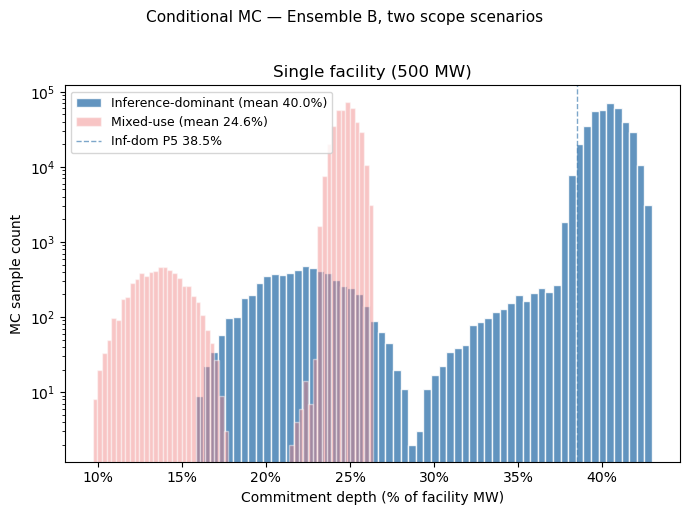

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure_2a.png


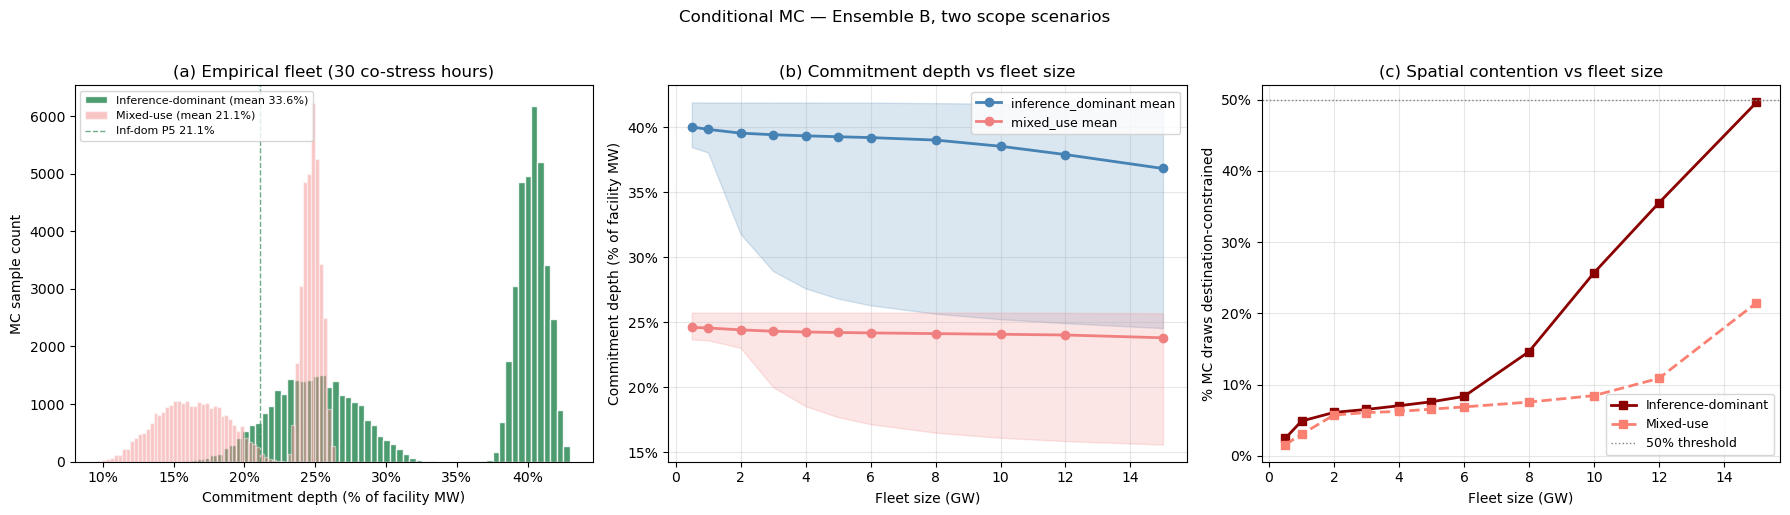

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure_2bcd.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-5a: STANDALONE PANEL (a) — SINGLE-FACILITY CONDITIONAL MC (Fig. 2a)
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

_inf_dom = SINGLE_FAC_RESULTS['inference_dominant']['commit_depths'].flatten()
_mix     = SINGLE_FAC_RESULTS['mixed_use']['commit_depths'].flatten()
ax.hist(_inf_dom * 100, bins=60, color='steelblue',
        edgecolor='white', alpha=0.85,
        label=f'Inference-dominant (mean {SINGLE_FAC_RESULTS["inference_dominant"]["mean_commit_depth"]:.1%})')
ax.hist(_mix * 100, bins=60, color='lightcoral',
        edgecolor='white', alpha=0.45,
        label=f'Mixed-use (mean {SINGLE_FAC_RESULTS["mixed_use"]["mean_commit_depth"]:.1%})')
ax.axvline(SINGLE_FAC_RESULTS['inference_dominant']['p5_commit_depth'] * 100,
           color='steelblue', linewidth=1, linestyle='--', alpha=0.7,
           label=f"Inf-dom P5 {SINGLE_FAC_RESULTS['inference_dominant']['p5_commit_depth']:.1%}")
ax.set_xlabel("Commitment depth (% of facility MW)")
ax.set_ylabel("MC sample count")
ax.set_title(f"Single facility ({SINGLE_FAC_MW} MW)")
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_yscale('log')

plt.suptitle(
    f"Conditional MC — Ensemble {DEFAULT_ENSEMBLE}, "
    f"two scope scenarios",
    fontsize=11, y=1.02,
)
plt.tight_layout()

_figpath = FIGURES_DIR / "figure_2a.png"
plt.savefig(_figpath, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved: {_figpath}")


# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-5b: THREE-PANEL FIGURE (b, c, d) — FLEET + SWEEP (Fig. 2bcd)
# ══════════════════════════════════════════════════════════════════════════════
# Three panels arranged horizontally:
#   (b) Empirical fleet (co-stress hours only): inf-dom primary, mixed-use overlay
#   (c) Per-GW commitment depth curve, both scopes, P5–P95 bands
#   (d) Per-GW destination-contention curve, both scopes
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─── Panel (b): Empirical fleet histogram, both scopes ──────────────────────
_ax = axes[0]
_inf_dom = EMPIRICAL_FLEET_RESULTS['inference_dominant']['commit_depths'].flatten()
_mix     = EMPIRICAL_FLEET_RESULTS['mixed_use']['commit_depths'].flatten()
_n_hours = EMPIRICAL_FLEET_RESULTS['inference_dominant']['n_co_stress_hours']
_ax.hist(_inf_dom * 100, bins=60, color='seagreen',
         edgecolor='white', alpha=0.85,
         label=f'Inference-dominant (mean {EMPIRICAL_FLEET_RESULTS["inference_dominant"]["mean_commit_depth"]:.1%})')
_ax.hist(_mix * 100, bins=60, color='lightcoral',
         edgecolor='white', alpha=0.45,
         label=f'Mixed-use (mean {EMPIRICAL_FLEET_RESULTS["mixed_use"]["mean_commit_depth"]:.1%})')
_ax.axvline(EMPIRICAL_FLEET_RESULTS['inference_dominant']['p5_commit_depth'] * 100,
            color='seagreen', linewidth=1, linestyle='--', alpha=0.7,
            label=f"Inf-dom P5 {EMPIRICAL_FLEET_RESULTS['inference_dominant']['p5_commit_depth']:.1%}")
_ax.set_xlabel("Commitment depth (% of facility MW)")
_ax.set_ylabel("MC sample count")
_ax.set_title(f"(a) Empirical fleet ({_n_hours} co-stress hours)")
_ax.legend(loc='upper left', fontsize=8)
_ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# ─── Panel (c): Per-GW sweep, both scopes ───────────────────────────────────
_ax = axes[1]
for _scope_label, _color in [('inference_dominant', 'steelblue'),
                              ('mixed_use',          'lightcoral')]:
    _df = sweep_results_by_scope[_scope_label]
    _ax.plot(_df['fleet_gw'], _df['mean'] * 100,
             color=_color, linewidth=2, marker='o',
             label=f"{_scope_label} mean")
    _ax.fill_between(_df['fleet_gw'],
                     _df['p5'] * 100, _df['p95'] * 100,
                     alpha=0.2, color=_color)
    _onset = contention_onset_gw_by_scope[_scope_label]
    if _onset is not None:
        _ax.axvline(_onset, color=_color, linewidth=1, linestyle='--', alpha=0.6)
_ax.set_xlabel("Fleet size (GW)")
_ax.set_ylabel("Commitment depth (% of facility MW)")
_ax.set_title("(b) Commitment depth vs fleet size")
_ax.legend(loc='upper right', fontsize=9)
_ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.grid(True, alpha=0.3)

# ─── Panel (d): Per-GW % constrained, both scopes ──────────────────────────
_ax = axes[2]
_df_id = sweep_results_by_scope['inference_dominant']
_df_mu = sweep_results_by_scope['mixed_use']
_ax.plot(_df_id['fleet_gw'], _df_id['pct_constrained'],
         color='darkred', linewidth=2, marker='s', label='Inference-dominant')
_ax.plot(_df_mu['fleet_gw'], _df_mu['pct_constrained'],
         color='salmon', linewidth=2, marker='s', linestyle='--',
         label='Mixed-use')
_ax.axhline(50, color='gray', linewidth=1, linestyle=':', label='50% threshold')
_ax.set_xlabel("Fleet size (GW)")
_ax.set_ylabel("% MC draws destination-constrained")
_ax.set_title("(c) Spatial contention vs fleet size")
_ax.legend(loc='lower right', fontsize=9)
_ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Conditional MC — Ensemble {DEFAULT_ENSEMBLE}, "
    f"two scope scenarios",
    fontsize=12, y=1.02,
)
plt.tight_layout()

_figpath = FIGURES_DIR / "figure_2bcd.png"
plt.savefig(_figpath, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved: {_figpath}")

## Part 4: Sensitivity Analysis (§5, Methods)

- **4-1** 2D sensitivity surface — D2 × D5 at 10 GW (Figure 6a)
- **4-2** Tornado chart — one-at-a-time at 10 GW (Figure 6b)

Evaluates how fleet commitment depth varies across the plausible ranges of
the dominant uncertainty parameters. D2 (utilization headroom) and D5
(pre-staging readiness) span the widest uncertainty and together with D4
account for the full sensitivity range. Source-side parameters show near-zero
sensitivity at fleet scale because the fleet is entirely destination-constrained.

### 4.1 2D Sensitivity Surface — D2 × D5 at 10 GW

Sweeps utilization headroom (D2) and pre-staging readiness (D5) across their full ranges on an 11 × 11 grid, with D3 and D4 held at central values. Commitment depth is computed deterministically per stress hour (no MC draws) at 10 GW fleet scale. Produces Figure 6a and `outputs/tables/sensitivity_surface.csv`.

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure6a_sensitivity_surface.png


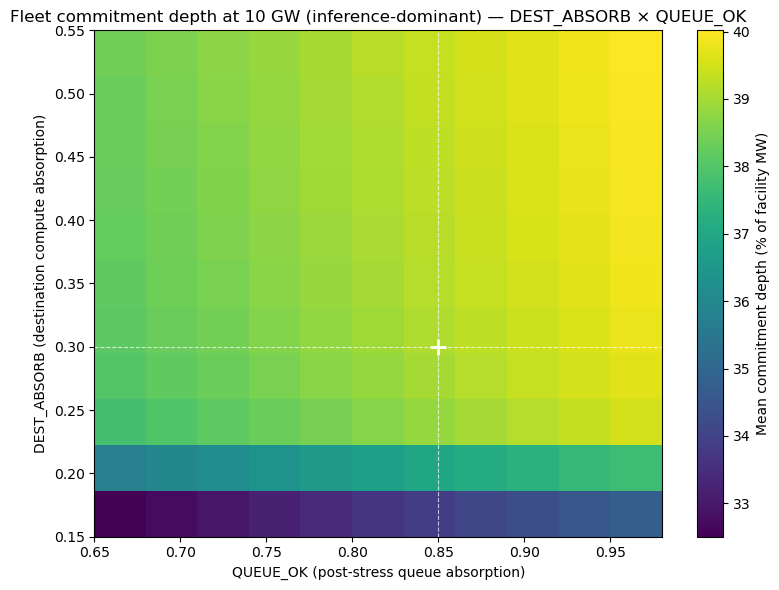


2D SENSITIVITY (10 GW, inference-dominant)
  DEST_ABSORB range: [0.15, 0.55]
  QUEUE_OK    range: [0.65, 0.98]
  Mean depth range:  [32.5%, 40.0%]
  Wrote sensitivity_surface.csv


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-1: 2D SENSITIVITY SURFACE — DEST_ABSORB × QUEUE_OK (Figure 6a)
# ══════════════════════════════════════════════════════════════════════════════
# Cross-mechanism sensitivity: spatial-binding vs deferral-binding parameters.
# Run under inference-dominant scope (headline). Other parameters at central
# Ensemble B values. DEST_AVAIL observed per-hour from parquet (the
# "conditional" layer). No MC draws — pure parameter surface.
# ══════════════════════════════════════════════════════════════════════════════

SENS_FLEET_MW = 10_000
SENS_PHI_INF  = PHI_INF_DOMINANT

_DA_lo, _DA_central, _DA_hi = PARAM_RANGES['DEST_ABSORB']
_QO_lo, _QO_central, _QO_hi = PARAM_RANGES['QUEUE_OK']

N_GRID = 11
_da_grid = np.linspace(_DA_lo, _DA_hi, N_GRID)
_qo_grid = np.linspace(_QO_lo, _QO_hi, N_GRID)

_fleet_inf_mw = SENS_FLEET_MW * (1.0 / PUE) * SENS_PHI_INF

surface_results = []
for _da in _da_grid:
    for _qo in _qo_grid:
        _params = _ensemble_params(DEFAULT_ENSEMBLE)
        _params['DEST_ABSORB'] = _da
        _params['QUEUE_OK'] = _qo

        _hour_depths = []
        for _h in range(n_stress_hours):
            _raw_avail_mw = sum(hour_dest_available_mw[_h].values())

            # Spatial step
            _wants = _fleet_inf_mw * _params['MIG_ELIG'] * _params['DRAIN_OK']
            _eff_headroom = _raw_avail_mw * _da
            _feas_spatial = (min(_wants, _eff_headroom)
                              * _params['NET_OK'] * _params['ORCH_OK'])

            # Deferral step
            _residual = _fleet_inf_mw - _feas_spatial
            _feas_defer = (_residual * _params['NIW_SHARE']
                            * _params['WINDOW_OK'] * _qo)

            # DVFS step
            _residual_after = _residual - _feas_defer
            _feas_dvfs = (_residual_after * _params['DVFS_HEADROOM']
                           * _params['DVFS_RELIABILITY'])

            _commit = (_feas_spatial + _feas_defer + _feas_dvfs) / SENS_FLEET_MW
            _hour_depths.append(_commit)

        surface_results.append({
            'dest_absorb':    _da,
            'queue_ok':       _qo,
            'mean_depth':     np.mean(_hour_depths),
            'p5_depth':       np.percentile(_hour_depths, 5),
        })

sensitivity_surface = pd.DataFrame(surface_results)

# ─── Figure ──────────────────────────────────────────────────────────────────
_pivot = sensitivity_surface.pivot(index='dest_absorb', columns='queue_ok',
                                     values='mean_depth')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
_im = ax.imshow(
    _pivot.values * 100,
    origin='lower',
    aspect='auto',
    extent=[_qo_grid[0], _qo_grid[-1], _da_grid[0], _da_grid[-1]],
    cmap='viridis',
)
fig.colorbar(_im, ax=ax, label='Mean commitment depth (% of facility MW)')

ax.axhline(_DA_central, color='white', ls='--', lw=0.8, alpha=0.7)
ax.axvline(_QO_central, color='white', ls='--', lw=0.8, alpha=0.7)
ax.plot(_QO_central, _DA_central, 'w+', ms=12, mew=2)

ax.set_xlabel('QUEUE_OK (post-stress queue absorption)')
ax.set_ylabel('DEST_ABSORB (destination compute absorption)')
ax.set_title(f'Fleet commitment depth at {SENS_FLEET_MW/1000:.0f} GW '
             f'(inference-dominant) — DEST_ABSORB × QUEUE_OK')

fig.tight_layout()
_fig_path = FIGURES_DIR / 'figure6a_sensitivity_surface.png'
fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {_fig_path}")
plt.show()

_min_d = sensitivity_surface['mean_depth'].min()
_max_d = sensitivity_surface['mean_depth'].max()
print(f"\n2D SENSITIVITY ({SENS_FLEET_MW/1000:.0f} GW, inference-dominant)")
print("=" * 60)
print(f"  DEST_ABSORB range: [{_DA_lo:.2f}, {_DA_hi:.2f}]")
print(f"  QUEUE_OK    range: [{_QO_lo:.2f}, {_QO_hi:.2f}]")
print(f"  Mean depth range:  [{_min_d:.1%}, {_max_d:.1%}]")

_csv_path = TABLES_DIR / 'sensitivity_surface.csv'
sensitivity_surface.to_csv(_csv_path, index=False)
print(f"  Wrote {_csv_path.name}")

### 4.2 Tornado Chart — One-at-a-Time at 10 GW

Sweeps each of the nine stochastic parameters (S1 is fixed) from its lower to upper bound while holding all others at central values. Identifies which parameters drive fleet-scale commitment depth variation and which are absorbed by destination contention. Produces Figure 6b and `outputs/tables/sensitivity_tornado.csv`.

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure6b_sensitivity_tornado.png


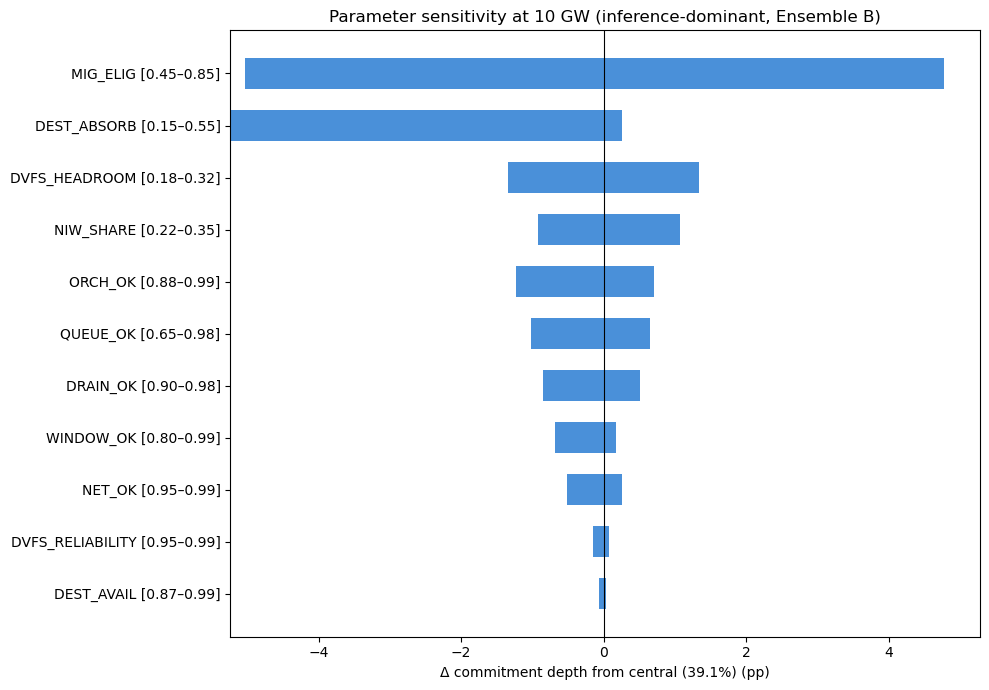


TORNADO (10 GW, inference-dominant, Ensemble B)
  Baseline (all central): 39.1%

  Param                |    Lo |    Hi |  Depth@Lo |  Depth@Hi |   Range
  ──────────────────────────────────────────────────────────────────────
  MIG_ELIG             |  0.45 |  0.85 |    34.1% |    43.9% |    9.8pp
  DEST_ABSORB          |  0.15 |  0.55 |    33.9% |    39.4% |    5.5pp
  DVFS_HEADROOM        |  0.18 |  0.32 |    37.8% |    40.5% |    2.7pp
  NIW_SHARE            |  0.22 |  0.35 |    38.2% |    40.2% |    2.0pp
  ORCH_OK              |  0.88 |  0.99 |    37.9% |    39.8% |    1.9pp
  QUEUE_OK             |  0.65 |  0.98 |    38.1% |    39.8% |    1.7pp
  DRAIN_OK             |  0.90 |  0.98 |    38.3% |    39.6% |    1.4pp
  WINDOW_OK            |  0.80 |  0.99 |    38.4% |    39.3% |    0.9pp
  NET_OK               |  0.95 |  0.99 |    38.6% |    39.4% |    0.8pp
  DVFS_RELIABILITY     |  0.95 |  0.99 |    39.0% |    39.2% |    0.2pp
  DEST_AVAIL           |  0.87 |  0.99 |    39.0% | 

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-2: TORNADO CHART — ONE-AT-A-TIME AT 10 GW (Figure 6b)
# ══════════════════════════════════════════════════════════════════════════════

TORNADO_FLEET_MW = 10_000
TORNADO_PHI_INF  = PHI_INF_DOMINANT

_swept_params = ['MIG_ELIG', 'DRAIN_OK', 'DEST_AVAIL', 'DEST_ABSORB',
                 'NET_OK', 'ORCH_OK', 'NIW_SHARE', 'WINDOW_OK', 'QUEUE_OK',
                 'DVFS_HEADROOM', 'DVFS_RELIABILITY']

def _compute_fleet_depth_deterministic(params, phi_inf, fleet_mw):
    """Mean commitment depth across stress hours at given parameter values."""
    fleet_inf_mw = fleet_mw * (1.0 / PUE) * phi_inf
    _depths = []
    for _h in range(n_stress_hours):
        _raw_avail_mw = sum(hour_dest_available_mw[_h].values())

        _wants = fleet_inf_mw * params['MIG_ELIG'] * params['DRAIN_OK']
        _avail_scaled = _raw_avail_mw * (params['DEST_AVAIL'] / DEST_AVAIL)
        _eff_headroom = _avail_scaled * params['DEST_ABSORB']
        _feas_spatial = (min(_wants, _eff_headroom)
                          * params['NET_OK'] * params['ORCH_OK'])

        _residual = fleet_inf_mw - _feas_spatial
        _feas_defer = (_residual * params['NIW_SHARE']
                        * params['WINDOW_OK'] * params['QUEUE_OK'])

        _residual_after = _residual - _feas_defer
        _feas_dvfs = (_residual_after * params['DVFS_HEADROOM']
                       * params['DVFS_RELIABILITY'])

        _depths.append((_feas_spatial + _feas_defer + _feas_dvfs) / fleet_mw)
    return np.mean(_depths)

_central_params = _ensemble_params(DEFAULT_ENSEMBLE)
_baseline_depth = _compute_fleet_depth_deterministic(
    _central_params, TORNADO_PHI_INF, TORNADO_FLEET_MW
)

tornado_results = []
for _p in _swept_params:
    _range = ENSEMBLE_OVERRIDES.get(DEFAULT_ENSEMBLE, {}).get(_p, PARAM_RANGES[_p])
    _lo, _cen, _hi = _range

    _params_lo = dict(_central_params); _params_lo[_p] = _lo
    _params_hi = dict(_central_params); _params_hi[_p] = _hi

    _d_lo = _compute_fleet_depth_deterministic(_params_lo, TORNADO_PHI_INF,
                                                  TORNADO_FLEET_MW)
    _d_hi = _compute_fleet_depth_deterministic(_params_hi, TORNADO_PHI_INF,
                                                  TORNADO_FLEET_MW)

    tornado_results.append({
        'param': _p, 'lo_val': _lo, 'hi_val': _hi,
        'depth_at_lo': _d_lo, 'depth_at_hi': _d_hi,
        'range_pp': abs(_d_hi - _d_lo) * 100,
    })

tornado_df = pd.DataFrame(tornado_results).sort_values('range_pp', ascending=True)

# ─── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
_y_pos = range(len(tornado_df))
_lo_d = (tornado_df['depth_at_lo'].values - _baseline_depth) * 100
_hi_d = (tornado_df['depth_at_hi'].values - _baseline_depth) * 100

ax.barh(_y_pos, _hi_d - _lo_d, left=_lo_d,
        color='#4a90d9', edgecolor='none', height=0.6)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(list(_y_pos))
ax.set_yticklabels([f"{r['param']} [{r['lo_val']:.2f}–{r['hi_val']:.2f}]"
                     for _, r in tornado_df.iterrows()])
ax.set_xlabel(f'Δ commitment depth from central ({_baseline_depth:.1%}) (pp)')
ax.set_title(f'Parameter sensitivity at {TORNADO_FLEET_MW/1000:.0f} GW '
             f'(inference-dominant, Ensemble {DEFAULT_ENSEMBLE})')

fig.tight_layout()
_fig_path = FIGURES_DIR / 'figure6b_sensitivity_tornado.png'
fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {_fig_path}")
plt.show()

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f"\nTORNADO ({TORNADO_FLEET_MW/1000:.0f} GW, inference-dominant, "
      f"Ensemble {DEFAULT_ENSEMBLE})")
print("=" * 74)
print(f"  Baseline (all central): {_baseline_depth:.1%}")
print()
print(f"  {'Param':<20} | {'Lo':>5} | {'Hi':>5} | {'Depth@Lo':>9} | "
      f"{'Depth@Hi':>9} | {'Range':>7}")
print("  " + "─" * 70)
for _, _r in tornado_df.iloc[::-1].iterrows():
    print(f"  {_r['param']:<20} | {_r['lo_val']:>5.2f} | {_r['hi_val']:>5.2f} | "
          f"{_r['depth_at_lo']:>8.1%} | {_r['depth_at_hi']:>8.1%} | "
          f"{_r['range_pp']:>6.1f}pp")

_csv_path = TABLES_DIR / 'sensitivity_tornado.csv'
tornado_df.to_csv(_csv_path, index=False)
print(f"\n  Wrote {_csv_path.name}")

## Part 5: Contract Exports

Writes two JSON contracts consumed by notebook 03, plus the sensitivity CSVs
already written in Part 4:

1. `outputs/contracts/cascade_parameters.json` — ten parameters, ranges, variance shares, cascade products
2. `outputs/contracts/conditional_mc_results.json` — single-facility, empirical fleet, per-GW sweep, contention onset

Running this Part overwrites these files. Do not hand-edit; regenerate by
re-running this notebook.

### 5.1 Export Cascade Parameters

Writes `outputs/contracts/cascade_parameters.json` — consumed by notebook 03 Part 0. Contains the ten-parameter definitions, ranges, grounding tags, static cascade products (conservative/central/optimistic), commitment depth baseline, and variance decomposition η² shares.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-1: EXPORT cascade_parameters.json — REFORMED FRAMEWORK
# ══════════════════════════════════════════════════════════════════════════════
# Schema v2.0. Restructured for three-mechanism + two-scope reporting.
# Consumed by notebook 03 Part 0.
# ══════════════════════════════════════════════════════════════════════════════

_grounding = {
    'PHI_INF_MIXED':    'DATA',
    'PHI_INF_DOMINANT': 'STRUCTURAL',
    'MIG_ELIG':         'MIXED (DATA + ESTIMATED-WEAK)',
    'DRAIN_OK':         'DATA',
    'DEST_AVAIL':       'DATA',
    'DEST_ABSORB':      'ESTIMATED-WEAK',
    'NET_OK':           'DATA',
    'ORCH_OK':          'ESTIMATED-MODERATE',
    'NIW_SHARE':        'DATA (Ensemble B); STRUCTURAL (A, C)',
    'WINDOW_OK':        'DERIVED',
    'QUEUE_OK':         'ESTIMATED-MODERATE',
    'DVFS_HEADROOM':    'DATA (Ensemble B); STRUCTURAL (A, C)',
    'DVFS_RELIABILITY': 'DATA',
}

def _serialize_param(p, ensemble_overrides=None):
    if ensemble_overrides and p in ensemble_overrides:
        _range = ensemble_overrides[p]
    else:
        _range = PARAM_RANGES[p]
    return {
        'central': float(_range[1]),
        'range': [float(_range[0]), float(_range[1]), float(_range[2])],
        'grounding': _grounding[p],
    }

cascade_contract = {
    'version': '2.0',
    'produced_by': 'notebook 02 — cascade_simulation (reformed framework)',
    'framework': 'eleven-parameter, three composable mechanisms, additive composition',
    'pue': PUE,
    'default_ensemble': DEFAULT_ENSEMBLE,

    'scope_scenarios': {
        'mixed_use':         _serialize_param('PHI_INF_MIXED'),
        'inference_dominant': _serialize_param('PHI_INF_DOMINANT'),
    },

    'spatial_cascade': {
        p: _serialize_param(p) for p in
        ['MIG_ELIG', 'DRAIN_OK', 'DEST_AVAIL', 'DEST_ABSORB', 'NET_OK', 'ORCH_OK']
    },

    'deferral_cascade': {
        p: _serialize_param(p) for p in ['NIW_SHARE', 'WINDOW_OK', 'QUEUE_OK']
    },

    'dvfs_cascade': {
        p: _serialize_param(p) for p in ['DVFS_HEADROOM', 'DVFS_RELIABILITY']
    },

    'ensemble_overrides': {
        _ens: {p: list(map(float, _r)) for p, _r in _ovr.items()}
        for _ens, _ovr in ENSEMBLE_OVERRIDES.items()
    },

    'static_commitment_depth_central': {
        'mixed_use':         float(STATIC_DEPTH_MIXED['commit_depth']),
        'inference_dominant': float(STATIC_DEPTH_DOMINANT['commit_depth']),
    },

    'variance_decomposition_eta_squared': {
        scope: {p: float(v) for p, v in _eta_dict.items()}
        for scope, _eta_dict in CASCADE_ETA_SQ.items()
    },

    'notes': (
        'Eleven-parameter framework from NE paper (reformed). Three composable '
        'mechanisms (spatial / deferral / DVFS) compose additively at MW layer '
        'with sequential ordering. No "floor" concept under reformed framework — '
        'tail behavior reported via P5 / CVaR of conditional MC. '
        'Scope scenarios reported in parallel.'
    ),
}

_path = CONTRACTS_DIR / 'cascade_parameters.json'
with open(_path, 'w') as f:
    json.dump(cascade_contract, f, indent=2)

print(f"✓ Wrote {_path.name}")
print(f"  Schema version:           {cascade_contract['version']}")
print(f"  Mixed-use static depth:   {cascade_contract['static_commitment_depth_central']['mixed_use']:.1%}")
print(f"  Inf-dominant static depth: {cascade_contract['static_commitment_depth_central']['inference_dominant']:.1%}")
print(f"  Spatial parameters:       {len(cascade_contract['spatial_cascade'])}")
print(f"  Deferral parameters:      {len(cascade_contract['deferral_cascade'])}")
print(f"  DVFS parameters:          {len(cascade_contract['dvfs_cascade'])}")

✓ Wrote cascade_parameters.json
  Schema version:           2.0
  Mixed-use static depth:   16.9%
  Inf-dominant static depth: 27.5%
  Spatial parameters:       6
  Deferral parameters:      3
  DVFS parameters:          2


### 5.2 Export Conditional MC Results

Writes `outputs/contracts/conditional_mc_results.json` — consumed by notebook 03 Parts 1–2. Contains single-facility and empirical fleet results, the full per-GW sweep table, contention onset, and sensitivity summary statistics.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-2: EXPORT conditional_mc_results.json — REFORMED FRAMEWORK
# ══════════════════════════════════════════════════════════════════════════════
# Schema v2.0. Two scopes reported in parallel.
# Consumed by notebook 03 Parts 1–4.
# ══════════════════════════════════════════════════════════════════════════════

def _strip_arrays(d):
    """Remove numpy arrays from results dicts before serializing."""
    return {k: v for k, v in d.items() if not isinstance(v, np.ndarray)}

conditional_mc_contract = {
    'version': '2.0',
    'produced_by': 'notebook 02 — cascade_simulation (reformed framework)',
    'framework': 'eleven-parameter, three composable mechanisms',
    'n_draws_per_hour': N_DRAWS,
    'n_stress_hours': n_stress_hours,
    'source_zone': 'PJM_COMED',
    'pue': PUE,
    'ensemble': DEFAULT_ENSEMBLE,
    'parameter_scheme': CONDITIONAL_MC_CONFIG,

    'single_facility_500mw': {
        scope: _strip_arrays(_r) for scope, _r in SINGLE_FAC_RESULTS.items()
    },

    'empirical_fleet': {
        scope: _strip_arrays(_r) for scope, _r in EMPIRICAL_FLEET_RESULTS.items()
    },

    'per_gw_sweep': {
        scope: _df.to_dict(orient='records')
        for scope, _df in sweep_results_by_scope.items()
    },

    'contention_onset_gw': contention_onset_gw_by_scope,

    'sensitivity': {
        'surface': {
            'fleet_mw': SENS_FLEET_MW,
            'scope': 'inference_dominant',
            'sweep_axes': ['DEST_ABSORB', 'QUEUE_OK'],
            'depth_range': [
                float(sensitivity_surface['mean_depth'].min()),
                float(sensitivity_surface['mean_depth'].max()),
            ],
        },
        'tornado': {
            'fleet_mw': TORNADO_FLEET_MW,
            'scope': 'inference_dominant',
            'baseline_depth': float(_baseline_depth),
            'parameters_swept': _swept_params,
        },
    },
}

_path = CONTRACTS_DIR / 'conditional_mc_results.json'
with open(_path, 'w') as f:
    json.dump(conditional_mc_contract, f, indent=2, default=str)

print(f"✓ Wrote {_path.name}")
print(f"  Schema version:        {conditional_mc_contract['version']}")
for _scope_label in ('mixed_use', 'inference_dominant'):
    _r = SINGLE_FAC_RESULTS[_scope_label]
    print(f"  Single fac {_scope_label:<20}: mean={_r['mean_commit_depth']:.1%}  "
          f"P5={_r['p5_commit_depth']:.1%}")
for _scope_label in ('mixed_use', 'inference_dominant'):
    _r = EMPIRICAL_FLEET_RESULTS[_scope_label]
    print(f"  Empirical fleet {_scope_label:<15}: mean={_r['mean_commit_depth']:.1%}  "
          f"P5={_r['p5_commit_depth']:.1%}  "
          f"({_r['n_co_stress_hours']}/{_r['n_stress_hours_total']} co-stress hours)")

✓ Wrote conditional_mc_results.json
  Schema version:        2.0
  Single fac mixed_use           : mean=24.6%  P5=23.7%
  Single fac inference_dominant  : mean=40.0%  P5=38.5%
  Empirical fleet mixed_use      : mean=21.1%  P5=13.2%  (30/200 co-stress hours)
  Empirical fleet inference_dominant: mean=33.6%  P5=21.1%  (30/200 co-stress hours)


## CELL A2 PJM_DOM Run

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 6-1 (APPENDED): DOM-AS-SOURCE EMPIRICAL FLEET — robustness check
# ══════════════════════════════════════════════════════════════════════════════
# Mirrors Cell 3-2 (single facility) and Cell 3-3 (empirical fleet) with DOM
# as source. Reads from per_hour_destination_availability_DOM.parquet.
#
# OUTPUTS: SINGLE_FAC_RESULTS_DOM and EMPIRICAL_FLEET_RESULTS_DOM
#          (parallel to existing ComEd-source dicts)
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

ALT_PARQUET_PATH = CONTRACTS_DIR / "per_hour_destination_availability_DOM.parquet"

assert ALT_PARQUET_PATH.exists(), (
    f"{ALT_PARQUET_PATH} not found. Run NB01 Cell 4-4 (DOM parquet generator) first."
)

alt_per_hour_avail = pd.read_parquet(ALT_PARQUET_PATH)

# Reconstruct hour data structures parallel to those used in Cells 3-1/3-2/3-3
_alt_dest_cols = [c for c in alt_per_hour_avail.columns
                   if c not in ('timestamp', 'pjm_co_stressed_mw')]

alt_hour_dest_available_mw = []
for _, _row in alt_per_hour_avail.iterrows():
    _avail = {_z: float(_row[_z]) for _z in _alt_dest_cols if _row[_z] > 0}
    alt_hour_dest_available_mw.append(_avail)

alt_hour_pjm_co_stressed_mw = alt_per_hour_avail['pjm_co_stressed_mw'].astype(float).tolist()
alt_n_stress_hours = len(alt_per_hour_avail)

print(f"DOM-AS-SOURCE ROBUSTNESS CHECK")
print("=" * 78)
print(f"  Loaded parquet:        {ALT_PARQUET_PATH.name}")
print(f"  DOM stress hours:      {alt_n_stress_hours}")
print(f"  Cross-RTO dest zones:  {len(_alt_dest_cols)}")
print()

# ─── Single-facility (500 MW) under DOM-source destination conditions ───────
print("─" * 78)
print("SINGLE FACILITY (500 MW) — DOM-source destination conditions")
print("─" * 78)

SINGLE_FAC_RESULTS_DOM = {}

for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                            ('inference_dominant', PHI_INF_DOMINANT)]:
    _commit = np.zeros((alt_n_stress_hours, N_DRAWS))

    for _h in range(alt_n_stress_hours):
        _raw_avail_mw = sum(alt_hour_dest_available_mw[_h].values())
        _result = _compute_single_fac_hour(_raw_avail_mw, _phi, SINGLE_FAC_MW)
        _commit[_h, :] = _result['commit_depth']

    _flat = _commit.flatten()
    _p5 = np.percentile(_flat, 5)
    _cvar5 = _flat[_flat <= _p5].mean()

    SINGLE_FAC_RESULTS_DOM[_scope_label] = {
        'phi_inf':             _phi,
        'mean_commit_depth':   float(_flat.mean()),
        'median_commit_depth': float(np.median(_flat)),
        'p5_commit_depth':     float(_p5),
        'p95_commit_depth':    float(np.percentile(_flat, 95)),
        'cvar5':               float(_cvar5),
    }

    print(f"\n  Scope: {_scope_label} (phi_inf = {_phi})")
    print(f"    Mean:   {SINGLE_FAC_RESULTS_DOM[_scope_label]['mean_commit_depth']:.1%}")
    print(f"    Median: {SINGLE_FAC_RESULTS_DOM[_scope_label]['median_commit_depth']:.1%}")
    print(f"    [P5, P95]: [{SINGLE_FAC_RESULTS_DOM[_scope_label]['p5_commit_depth']:.1%}, "
          f"{SINGLE_FAC_RESULTS_DOM[_scope_label]['p95_commit_depth']:.1%}]")
    print(f"    CVaR (below P5): {SINGLE_FAC_RESULTS_DOM[_scope_label]['cvar5']:.1%}")

# ─── Empirical fleet (PJM-outside-DOM) ──────────────────────────────────────
print()
print("─" * 78)
print("EMPIRICAL FLEET (PJM ex-DOM) — DOM-source")
print("─" * 78)

# Restrict to hours with co-stress > 0 (same Option A logic as ComEd analysis)
alt_hours_with_co_stress = [_h for _h in range(alt_n_stress_hours)
                              if alt_hour_pjm_co_stressed_mw[_h] > 0]
alt_n_co_stress_hours = len(alt_hours_with_co_stress)

if alt_n_co_stress_hours == 0:
    print("\n  WARNING: zero co-stress hours for DOM-as-source.")
    print("  PJM zones outside DOM never simultaneously stressed during DOM events.")
    print("  This is itself a robustness finding — empirical fleet question is")
    print("  not well-defined in this configuration.")
    EMPIRICAL_FLEET_RESULTS_DOM = None
else:
    EMPIRICAL_FLEET_RESULTS_DOM = {}

    for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                                ('inference_dominant', PHI_INF_DOMINANT)]:
        _commit = np.zeros((alt_n_co_stress_hours, N_DRAWS))
        _fleet_mw_per_hour = np.zeros(alt_n_co_stress_hours)

        for _i, _h in enumerate(alt_hours_with_co_stress):
            _co_stressed_mw = alt_hour_pjm_co_stressed_mw[_h]
            _fleet_mw_per_hour[_i] = _co_stressed_mw

            _result = _compute_single_fac_hour(
                sum(alt_hour_dest_available_mw[_h].values()),
                _phi,
                _co_stressed_mw,
            )
            _commit[_i, :] = _result['commit_depth']

        _flat = _commit.flatten()
        _p5 = np.percentile(_flat, 5)
        _cvar5 = _flat[_flat <= _p5].mean() if (_flat <= _p5).any() else _p5

        EMPIRICAL_FLEET_RESULTS_DOM[_scope_label] = {
            'phi_inf':                 _phi,
            'mean_commit_depth':       float(_flat.mean()),
            'median_commit_depth':     float(np.median(_flat)),
            'p5_commit_depth':         float(_p5),
            'p95_commit_depth':        float(np.percentile(_flat, 95)),
            'cvar5':                   float(_cvar5),
            'mean_migrating_mw':       float(_fleet_mw_per_hour.mean()),
            'max_migrating_mw':        float(_fleet_mw_per_hour.max()),
            'n_co_stress_hours':       alt_n_co_stress_hours,
        }

    print(f"\n  Co-stress hours: {alt_n_co_stress_hours} / {alt_n_stress_hours}")
    print(f"  Migrating fleet (mean): {EMPIRICAL_FLEET_RESULTS_DOM['inference_dominant']['mean_migrating_mw']:,.0f} MW")
    print(f"  Migrating fleet (max):  {EMPIRICAL_FLEET_RESULTS_DOM['inference_dominant']['max_migrating_mw']:,.0f} MW")

    for _scope_label, _r in EMPIRICAL_FLEET_RESULTS_DOM.items():
        print(f"\n  Scope: {_scope_label} (phi_inf = {_r['phi_inf']})")
        print(f"    Mean:   {_r['mean_commit_depth']:.1%}")
        print(f"    Median: {_r['median_commit_depth']:.1%}")
        print(f"    [P5, P95]: [{_r['p5_commit_depth']:.1%}, {_r['p95_commit_depth']:.1%}]")
        print(f"    CVaR (below P5): {_r['cvar5']:.1%}")

# ─── Side-by-side comparison: ComEd vs DOM ──────────────────────────────────
print()
print("=" * 78)
print("ROBUSTNESS COMPARISON: ComEd-source vs DOM-source")
print("=" * 78)
print(f"\n  Single facility (inference-dominant, 500 MW):")
print(f"    ComEd: mean {SINGLE_FAC_RESULTS['inference_dominant']['mean_commit_depth']:.1%}  "
      f"P5 {SINGLE_FAC_RESULTS['inference_dominant']['p5_commit_depth']:.1%}")
print(f"    DOM:   mean {SINGLE_FAC_RESULTS_DOM['inference_dominant']['mean_commit_depth']:.1%}  "
      f"P5 {SINGLE_FAC_RESULTS_DOM['inference_dominant']['p5_commit_depth']:.1%}")

if EMPIRICAL_FLEET_RESULTS_DOM is not None:
    print(f"\n  Empirical fleet (inference-dominant):")
    print(f"    ComEd: mean {EMPIRICAL_FLEET_RESULTS['inference_dominant']['mean_commit_depth']:.1%}  "
          f"P5 {EMPIRICAL_FLEET_RESULTS['inference_dominant']['p5_commit_depth']:.1%}  "
          f"({EMPIRICAL_FLEET_RESULTS['inference_dominant']['n_co_stress_hours']} co-stress hours)")
    print(f"    DOM:   mean {EMPIRICAL_FLEET_RESULTS_DOM['inference_dominant']['mean_commit_depth']:.1%}  "
          f"P5 {EMPIRICAL_FLEET_RESULTS_DOM['inference_dominant']['p5_commit_depth']:.1%}  "
          f"({EMPIRICAL_FLEET_RESULTS_DOM['inference_dominant']['n_co_stress_hours']} co-stress hours)")

print()
print("INTERPRETATION:")
print("  If DOM-source results are within ~5pp of ComEd-source on mean depth,")
print("  the empirical fleet finding is robust to source-zone choice within PJM.")
print("  Larger gaps would suggest the result is PJM-internal-geography specific.")

DOM-AS-SOURCE ROBUSTNESS CHECK
  Loaded parquet:        per_hour_destination_availability_DOM.parquet
  DOM stress hours:      200
  Cross-RTO dest zones:  17

──────────────────────────────────────────────────────────────────────────────
SINGLE FACILITY (500 MW) — DOM-source destination conditions
──────────────────────────────────────────────────────────────────────────────

  Scope: mixed_use (phi_inf = 0.43)
    Mean:   24.7%
    Median: 24.8%
    [P5, P95]: [23.8%, 25.8%]
    CVaR (below P5): 22.6%

  Scope: inference_dominant (phi_inf = 0.7)
    Mean:   40.2%
    Median: 40.4%
    [P5, P95]: [38.7%, 41.9%]
    CVaR (below P5): 36.7%

──────────────────────────────────────────────────────────────────────────────
EMPIRICAL FLEET (PJM ex-DOM) — DOM-source
──────────────────────────────────────────────────────────────────────────────

  Co-stress hours: 145 / 200
  Migrating fleet (mean): 4,043 MW
  Migrating fleet (max):  6,678 MW

  Scope: mixed_use (phi_inf = 0.43)
    Mean:   24.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 6-2 (APPENDED): MULTI-SOURCE CASCADE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
# Reads the four per-source parquets generated by NB01 Cell 4-5 and runs:
#   1. Single-facility (500 MW) commitment depth, both scopes, all four sources
#   2. Per-GW fleet sweep, both scopes, all four sources
#   3. Empirical fleet (PJM sources only — well-defined intra-RTO fleet)
#
# OUTPUTS: MULTI_SOURCE_RESULTS dict + comparison tables + per-source contracts
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

MULTI_SOURCE_ZONES = ['PJM_COMED', 'PJM_DOM', 'ERCOT_LZ_NORTH', 'CAISO_NP15']

# Verify parquets exist
for source_zone in MULTI_SOURCE_ZONES:
    _path = CONTRACTS_DIR / f"per_hour_destination_availability_{source_zone}.parquet"
    assert _path.exists(), (
        f"{_path} not found. Run NB01 Cell 4-5 first."
    )

print("MULTI-SOURCE CASCADE ANALYSIS")
print("=" * 90)
print(f"  Sources: {MULTI_SOURCE_ZONES}")
print(f"  Scopes:  mixed_use ({PHI_INF_MIXED}), inference_dominant ({PHI_INF_DOMINANT})")
print(f"  MC draws per stress hour: {N_DRAWS:,}")
print()

MULTI_SOURCE_RESULTS = {}

for source_zone in MULTI_SOURCE_ZONES:
    print(f"\n{'='*90}")
    print(f"SOURCE: {source_zone}")
    print('='*90)
    
    # Load source-specific parquet
    _path = CONTRACTS_DIR / f"per_hour_destination_availability_{source_zone}.parquet"
    src_avail = pd.read_parquet(_path)
    src_dest_cols = [c for c in src_avail.columns 
                      if c not in ('timestamp', 'pjm_co_stressed_mw')]
    
    src_hour_dest_available_mw = []
    for _, _row in src_avail.iterrows():
        _avail = {_z: float(_row[_z]) for _z in src_dest_cols if _row[_z] > 0}
        src_hour_dest_available_mw.append(_avail)
    
    src_hour_co_stressed_mw = src_avail['pjm_co_stressed_mw'].astype(float).tolist()
    src_n_stress_hours = len(src_avail)
    
    print(f"\n  Stress hours: {src_n_stress_hours}")
    print(f"  Cross-BA destinations: {len(src_dest_cols)}")
    
    # Determine if intra-RTO fleet analysis applies
    has_intra_rto_fleet = source_zone.startswith('PJM_') and any(
        m > 0 for m in src_hour_co_stressed_mw
    )
    
    # ─── Single facility (500 MW) ──────────────────────────────────────────
    single_fac_results = {}
    for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                                ('inference_dominant', PHI_INF_DOMINANT)]:
        _commit = np.zeros((src_n_stress_hours, N_DRAWS))
        for _h in range(src_n_stress_hours):
            _raw_avail_mw = sum(src_hour_dest_available_mw[_h].values())
            _result = _compute_single_fac_hour(_raw_avail_mw, _phi, SINGLE_FAC_MW)
            _commit[_h, :] = _result['commit_depth']
        
        _flat = _commit.flatten()
        _p5 = np.percentile(_flat, 5)
        _cvar5 = _flat[_flat <= _p5].mean()
        
        single_fac_results[_scope_label] = {
            'mean_commit_depth':   float(_flat.mean()),
            'median_commit_depth': float(np.median(_flat)),
            'p5_commit_depth':     float(_p5),
            'p95_commit_depth':    float(np.percentile(_flat, 95)),
            'cvar5':               float(_cvar5),
        }
    
    print(f"\n  SINGLE FACILITY ({SINGLE_FAC_MW} MW):")
    for _scope_label in ('mixed_use', 'inference_dominant'):
        _r = single_fac_results[_scope_label]
        print(f"    {_scope_label:<22}: mean {_r['mean_commit_depth']:.1%}  "
              f"P5 {_r['p5_commit_depth']:.1%}  CVaR {_r['cvar5']:.1%}")
    
    # ─── Per-GW sweep (subset to 1, 5, 10 GW for compactness; can expand) ──
    SWEEP_REPORT_GW = [1.0, 5.0, 10.0]
    sweep_results = {}
    for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                                ('inference_dominant', PHI_INF_DOMINANT)]:
        _rows = []
        for _fleet_gw in SWEEP_REPORT_GW:
            _fleet_mw = _fleet_gw * 1000
            _gw_commit = np.zeros((src_n_stress_hours, N_DRAWS))
            _gw_constrained = np.zeros((src_n_stress_hours, N_DRAWS), dtype=bool)
            
            for _h in range(src_n_stress_hours):
                _raw_avail_mw = sum(src_hour_dest_available_mw[_h].values())
                _result = _compute_single_fac_hour(_raw_avail_mw, _phi, _fleet_mw)
                _gw_commit[_h, :] = _result['commit_depth']
                _wants = _result['wants_to_migrate']
                if _wants > 0:
                    _gw_constrained[_h, :] = _result['effective_headroom'] < _wants
            
            _flat = _gw_commit.flatten()
            _rows.append({
                'fleet_gw': _fleet_gw,
                'mean': float(_flat.mean()),
                'p5': float(np.percentile(_flat, 5)),
                'pct_constrained': float(100 * _gw_constrained.mean()),
            })
        sweep_results[_scope_label] = pd.DataFrame(_rows)
    
    print(f"\n  PER-GW SWEEP (inference-dominant scope):")
    print(f"    {'Fleet':>6} | {'Mean':>7} | {'P5':>7} | {'% Constr':>9}")
    for _, _r in sweep_results['inference_dominant'].iterrows():
        print(f"    {_r['fleet_gw']:>4.1f}GW | {_r['mean']:>6.1%} | "
              f"{_r['p5']:>6.1%} | {_r['pct_constrained']:>8.1f}%")
    
    # ─── Empirical fleet (PJM sources only) ────────────────────────────────
    empirical_fleet_results = None
    if has_intra_rto_fleet:
        # Restrict to co-stress hours
        co_stress_idx = [_h for _h in range(src_n_stress_hours)
                         if src_hour_co_stressed_mw[_h] > 0]
        n_co = len(co_stress_idx)
        
        empirical_fleet_results = {}
        for _scope_label, _phi in [('mixed_use', PHI_INF_MIXED),
                                    ('inference_dominant', PHI_INF_DOMINANT)]:
            _commit = np.zeros((n_co, N_DRAWS))
            _fleet_mw = np.zeros(n_co)
            for _i, _h in enumerate(co_stress_idx):
                _co_mw = src_hour_co_stressed_mw[_h]
                _fleet_mw[_i] = _co_mw
                _result = _compute_single_fac_hour(
                    sum(src_hour_dest_available_mw[_h].values()), _phi, _co_mw)
                _commit[_i, :] = _result['commit_depth']
            
            _flat = _commit.flatten()
            _p5 = np.percentile(_flat, 5)
            _cvar5 = _flat[_flat <= _p5].mean() if (_flat <= _p5).any() else _p5
            
            empirical_fleet_results[_scope_label] = {
                'mean_commit_depth':   float(_flat.mean()),
                'median_commit_depth': float(np.median(_flat)),
                'p5_commit_depth':     float(_p5),
                'cvar5':               float(_cvar5),
                'n_co_stress_hours':   n_co,
                'mean_migrating_mw':   float(_fleet_mw.mean()),
                'max_migrating_mw':    float(_fleet_mw.max()),
            }
        
        print(f"\n  EMPIRICAL FLEET ({n_co} co-stress hours, "
              f"max {empirical_fleet_results['inference_dominant']['max_migrating_mw']:,.0f} MW):")
        for _scope_label in ('mixed_use', 'inference_dominant'):
            _r = empirical_fleet_results[_scope_label]
            print(f"    {_scope_label:<22}: mean {_r['mean_commit_depth']:.1%}  "
                  f"P5 {_r['p5_commit_depth']:.1%}  CVaR {_r['cvar5']:.1%}")
    else:
        print(f"\n  EMPIRICAL FLEET: skipped (no intra-RTO fleet structure for {source_zone})")
    
    MULTI_SOURCE_RESULTS[source_zone] = {
        'n_stress_hours':       src_n_stress_hours,
        'has_intra_rto_fleet':  has_intra_rto_fleet,
        'single_facility':      single_fac_results,
        'sweep':                {k: df.to_dict(orient='records') for k, df in sweep_results.items()},
        'empirical_fleet':      empirical_fleet_results,
    }


# ─── Side-by-side comparison ────────────────────────────────────────────────
print()
print("=" * 90)
print("CROSS-SOURCE COMPARISON — INFERENCE-DOMINANT SCOPE")
print("=" * 90)

print(f"\n  Single facility (500 MW):")
print(f"    {'Source':<22} | {'Mean':>7} | {'P5':>7} | {'CVaR':>7}")
print(f"    {'─' * 56}")
for source_zone in MULTI_SOURCE_ZONES:
    _r = MULTI_SOURCE_RESULTS[source_zone]['single_facility']['inference_dominant']
    print(f"    {source_zone:<22} | {_r['mean_commit_depth']:>6.1%} | "
          f"{_r['p5_commit_depth']:>6.1%} | {_r['cvar5']:>6.1%}")

print(f"\n  10 GW fleet:")
print(f"    {'Source':<22} | {'Mean':>7} | {'P5':>7} | {'% Constr':>9}")
print(f"    {'─' * 58}")
for source_zone in MULTI_SOURCE_ZONES:
    _records = MULTI_SOURCE_RESULTS[source_zone]['sweep']['inference_dominant']
    _10gw = next(r for r in _records if r['fleet_gw'] == 10.0)
    print(f"    {source_zone:<22} | {_10gw['mean']:>6.1%} | "
          f"{_10gw['p5']:>6.1%} | {_10gw['pct_constrained']:>8.1f}%")

print(f"\n  Empirical fleet (PJM sources only):")
print(f"    {'Source':<22} | {'Mean':>7} | {'P5':>7} | {'Hours':>7} | {'Max MW':>10}")
print(f"    {'─' * 65}")
for source_zone in MULTI_SOURCE_ZONES:
    _ef = MULTI_SOURCE_RESULTS[source_zone]['empirical_fleet']
    if _ef is None:
        print(f"    {source_zone:<22} | {'─':>7} | {'─':>7} | {'─':>7} | "
              f"{'no intra-RTO fleet':>10}")
    else:
        _r = _ef['inference_dominant']
        print(f"    {source_zone:<22} | {_r['mean_commit_depth']:>6.1%} | "
              f"{_r['p5_commit_depth']:>6.1%} | {_r['n_co_stress_hours']:>7d} | "
              f"{_r['max_migrating_mw']:>9,.0f}")

# ─── Export combined contract ───────────────────────────────────────────────
import json

multi_source_contract = {
    'version': '2.0',
    'produced_by': 'notebook 02 — multi-source cascade (appended cell)',
    'sources': MULTI_SOURCE_ZONES,
    'scopes': {
        'mixed_use': PHI_INF_MIXED,
        'inference_dominant': PHI_INF_DOMINANT,
    },
    'fleet_sizes_swept': SWEEP_REPORT_GW,
    'results': MULTI_SOURCE_RESULTS,
}

_path = CONTRACTS_DIR / 'multi_source_results.json'
with open(_path, 'w') as f:
    json.dump(multi_source_contract, f, indent=2, default=str)

print(f"\n✓ Wrote {_path.name}")

MULTI-SOURCE CASCADE ANALYSIS
  Sources: ['PJM_COMED', 'PJM_DOM', 'ERCOT_LZ_NORTH', 'CAISO_NP15']
  Scopes:  mixed_use (0.43), inference_dominant (0.7)
  MC draws per stress hour: 2,000


SOURCE: PJM_COMED

  Stress hours: 200
  Cross-BA destinations: 17

  SINGLE FACILITY (500 MW):
    mixed_use             : mean 24.6%  P5 23.7%  CVaR 20.6%
    inference_dominant    : mean 40.0%  P5 38.5%  CVaR 33.1%

  PER-GW SWEEP (inference-dominant scope):
     Fleet |    Mean |      P5 |  % Constr
     1.0GW |  39.8% |  38.1% |      4.9%
     5.0GW |  39.2% |  26.6% |      8.9%
    10.0GW |  38.2% |  24.9% |     29.0%

  EMPIRICAL FLEET (160 co-stress hours, max 14,464 MW):
    mixed_use             : mean 24.0%  P5 17.1%  CVaR 14.7%
    inference_dominant    : mean 38.0%  P5 25.7%  CVaR 22.9%

SOURCE: PJM_DOM

  Stress hours: 200
  Cross-BA destinations: 17

  SINGLE FACILITY (500 MW):
    mixed_use             : mean 24.7%  P5 23.8%  CVaR 22.6%
    inference_dominant    : mean 40.2%  P5 38.7% 

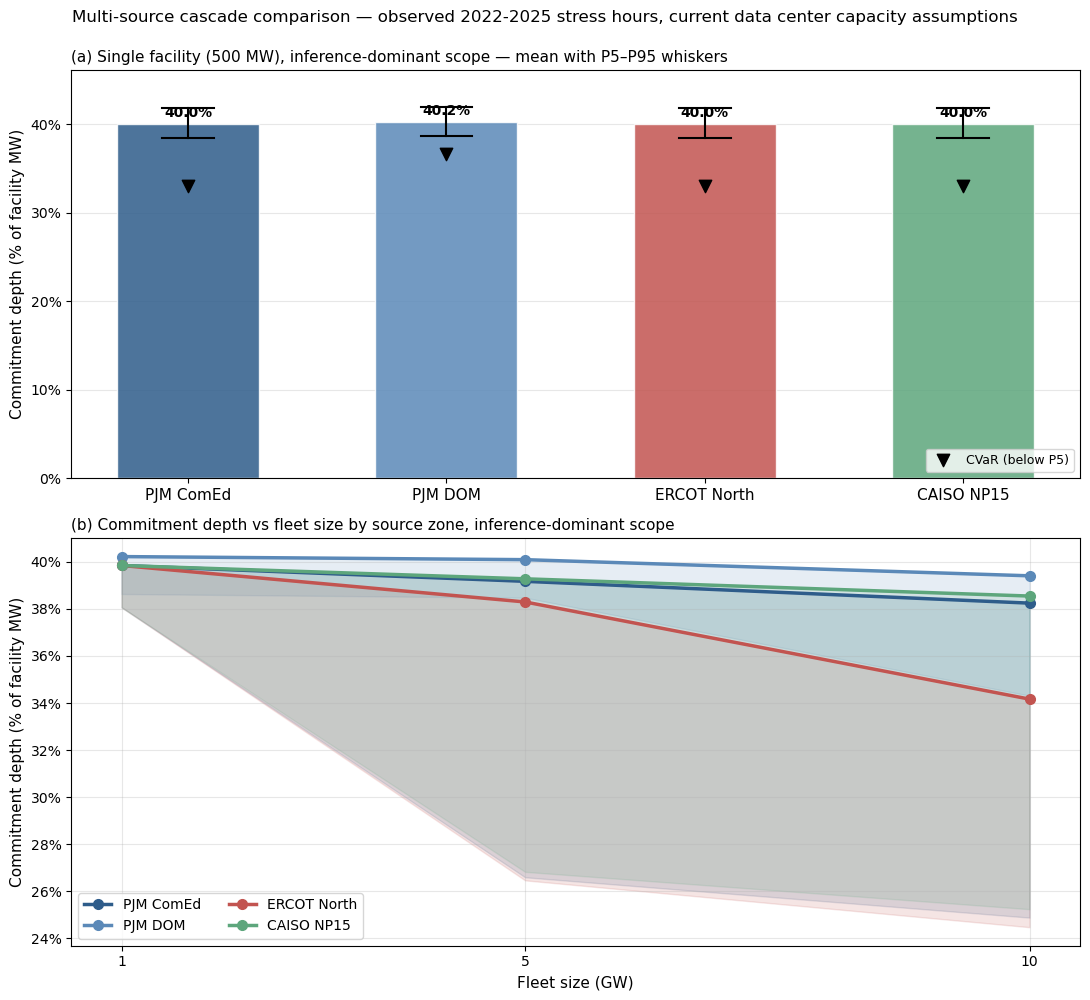

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure_multi_source_comparison.png

SUGGESTED FIGURE CAPTION:

Multi-source cascade analysis across four source zones spanning three U.S. 
interconnections (PJM Eastern, ERCOT, Western). Panel (a): Single-facility 
(500 MW) commitment depth under inference-dominant scope, with P5-P95 
whiskers and CVaR markers. Panel (b): Per-GW commitment depth curves with 
P5-mean shaded bands, showing scale-dependent saturation behavior. Stress 
hours are top 50 day-ahead LMP hours per year for each source zone over 
2022-2025; destination availability is evaluated against 17 cross-RTO 
zones using current data center capacity assumptions.


MULTI-SOURCE COMPARISON TABLE (for paper or extended data)
  Source                 | Single Fac |    1 GW |    5 GW |   10 GW
  ──────────────────────────────────────────────────────────────────────
  PJM ComEd              |     40.0% |  39.8% |  39.2% |  38.2%
  PJM

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 6-3 (APPENDED): MULTI-SOURCE COMPARISON FIGURE
# ══════════════════════════════════════════════════════════════════════════════
# Two-panel figure visualizing multi-source cascade results.
#   Panel (a): Single-facility (500 MW) commitment depth — bar chart with
#              mean + P5 + P95 across four source zones, inference-dominant scope
#   Panel (b): Per-GW sweep curves — four lines, one per source zone,
#              inference-dominant scope, mean with P5–P95 band
#
# All results from MULTI_SOURCE_RESULTS dict (produced by Cell 6-2).
# Restricted to inference-dominant scope as primary view; mixed-use available
# in MULTI_SOURCE_RESULTS for follow-up panels if desired.
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Verify upstream
assert 'MULTI_SOURCE_RESULTS' in dir(), (
    "MULTI_SOURCE_RESULTS not found. Run Cell 6-2 first."
)

# Color palette — distinct, accessible, and intuitive geographically
SOURCE_COLORS = {
    'PJM_COMED':       '#2E5C8A',  # blue (PJM)
    'PJM_DOM':         '#5B89B8',  # lighter blue (PJM)
    'ERCOT_LZ_NORTH':  '#C25450',  # red-orange (ERCOT)
    'CAISO_NP15':      '#5DA67C',  # green (Western)
}

SOURCE_LABELS = {
    'PJM_COMED':       'PJM ComEd',
    'PJM_DOM':         'PJM DOM',
    'ERCOT_LZ_NORTH':  'ERCOT North',
    'CAISO_NP15':      'CAISO NP15',
}

fig, axes = plt.subplots(2, 1, figsize=(11, 10))

# ─── Panel (a): Single-facility comparison ──────────────────────────────────
_ax = axes[0]

source_zones_ordered = ['PJM_COMED', 'PJM_DOM', 'ERCOT_LZ_NORTH', 'CAISO_NP15']
x_positions = np.arange(len(source_zones_ordered))

means = []
p5s = []
p95s = []
cvars = []
for source_zone in source_zones_ordered:
    _r = MULTI_SOURCE_RESULTS[source_zone]['single_facility']['inference_dominant']
    means.append(_r['mean_commit_depth'] * 100)
    p5s.append(_r['p5_commit_depth'] * 100)
    p95s.append(_r['p95_commit_depth'] * 100)
    cvars.append(_r['cvar5'] * 100)

# Bar chart with whiskers showing P5-P95 range
bar_colors = [SOURCE_COLORS[s] for s in source_zones_ordered]
bars = _ax.bar(x_positions, means, color=bar_colors, edgecolor='white',
                width=0.55, alpha=0.85, zorder=2)

# P5-P95 whiskers
for i, (mean, p5, p95) in enumerate(zip(means, p5s, p95s)):
    _ax.plot([i, i], [p5, p95], color='black', linewidth=1.5, zorder=3)
    _ax.plot([i - 0.1, i + 0.1], [p5, p5], color='black', linewidth=1.5, zorder=3)
    _ax.plot([i - 0.1, i + 0.1], [p95, p95], color='black', linewidth=1.5, zorder=3)

# CVaR markers (the lower-tail expected shortfall)
_ax.scatter(x_positions, cvars, marker='v', s=80, color='black',
             zorder=4, label='CVaR (below P5)')

# Annotate bars with mean values
for i, (bar, mean) in enumerate(zip(bars, means)):
    _ax.text(bar.get_x() + bar.get_width()/2, mean + 0.5,
              f'{mean:.1f}%', ha='center', va='bottom', fontsize=10,
              fontweight='semibold')

_ax.set_xticks(x_positions)
_ax.set_xticklabels([SOURCE_LABELS[s] for s in source_zones_ordered], fontsize=11)
_ax.set_ylabel('Commitment depth (% of facility MW)', fontsize=11)
_ax.set_title(f'(a) Single facility ({SINGLE_FAC_MW} MW), inference-dominant scope — '
               'mean with P5–P95 whiskers',
               fontsize=11, loc='left')
_ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.set_ylim(0, max(p95s) * 1.10)
_ax.grid(True, alpha=0.3, axis='y', zorder=0)
_ax.legend(loc='lower right', fontsize=9)

# ─── Panel (b): Per-GW sweep comparison ─────────────────────────────────────
_ax = axes[1]

for source_zone in source_zones_ordered:
    _records = MULTI_SOURCE_RESULTS[source_zone]['sweep']['inference_dominant']
    _df = pd.DataFrame(_records)
    _color = SOURCE_COLORS[source_zone]

    _ax.plot(_df['fleet_gw'], _df['mean'] * 100,
              color=_color, linewidth=2.5, marker='o', markersize=7,
              label=SOURCE_LABELS[source_zone])
    _ax.fill_between(_df['fleet_gw'],
                      _df['p5'] * 100, _df['mean'] * 100,
                      alpha=0.15, color=_color)

_ax.set_xlabel('Fleet size (GW)', fontsize=11)
_ax.set_ylabel('Commitment depth (% of facility MW)', fontsize=11)
_ax.set_title('(b) Commitment depth vs fleet size by source zone, '
               'inference-dominant scope',
               fontsize=11, loc='left')
_ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.set_xticks([1.0, 5.0, 10.0])
_ax.set_xticklabels(['1', '5', '10'])
_ax.set_xlim(0.5, 10.5)
_ax.grid(True, alpha=0.3)
_ax.legend(loc='lower left', fontsize=10, ncol=2)

# Suptitle with the right caveats baked in
plt.suptitle(
    'Multi-source cascade comparison — observed 2022-2025 stress hours, '
    'current data center capacity assumptions',
    fontsize=12, y=0.995,
)

plt.tight_layout()

_figpath = FIGURES_DIR / "figure_multi_source_comparison.png"
plt.savefig(_figpath, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved: {_figpath}")

# ─── Print the figure's caption text for paste-into-manuscript ───────────────
print()
print("=" * 78)
print("SUGGESTED FIGURE CAPTION:")
print("=" * 78)
print("""
Multi-source cascade analysis across four source zones spanning three U.S. 
interconnections (PJM Eastern, ERCOT, Western). Panel (a): Single-facility 
(500 MW) commitment depth under inference-dominant scope, with P5-P95 
whiskers and CVaR markers. Panel (b): Per-GW commitment depth curves with 
P5-mean shaded bands, showing scale-dependent saturation behavior. Stress 
hours are top 50 day-ahead LMP hours per year for each source zone over 
2022-2025; destination availability is evaluated against 17 cross-RTO 
zones using current data center capacity assumptions.
""")

# ─── Print summary table for paper/extended data ────────────────────────────
print()
print("MULTI-SOURCE COMPARISON TABLE (for paper or extended data)")
print("=" * 78)
print(f"  {'Source':<22} | {'Single Fac':>10} | {'1 GW':>7} | "
      f"{'5 GW':>7} | {'10 GW':>7}")
print(f"  {'─' * 70}")
for source_zone in source_zones_ordered:
    _sf = MULTI_SOURCE_RESULTS[source_zone]['single_facility']['inference_dominant']
    _records = MULTI_SOURCE_RESULTS[source_zone]['sweep']['inference_dominant']
    _1gw  = next(r for r in _records if r['fleet_gw'] == 1.0)
    _5gw  = next(r for r in _records if r['fleet_gw'] == 5.0)
    _10gw = next(r for r in _records if r['fleet_gw'] == 10.0)
    print(f"  {SOURCE_LABELS[source_zone]:<22} | {_sf['mean_commit_depth']:>9.1%} | "
          f"{_1gw['mean']:>6.1%} | {_5gw['mean']:>6.1%} | {_10gw['mean']:>6.1%}")
print()
print("All figures inference-dominant scope, Ensemble B central parameters.")
print("Range across sources at each fleet size indicates source-sensitivity.")